# EDA of crime reports in Mexico (2015 - 2025)

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from shadowroutes.config import settings

src_path = Path('../')
os.chdir(src_path)

In [2]:
# print("Data root:", settings.DATA_ROOT)
# print(Path.cwd())

## Parameters

In [3]:
# Data paths

# Crime report data (federal law) from SESNSP - obtained in October 2025
data_path_ff = Path(settings.DATA_ROOT / 'sesnsp' / 'raw' / 'Fuero_federal_2012-2015_sep2025.csv')

# Population estimates (mid-year) from CONAPO - obtained in October 2025
data_path_pop = Path(settings.DATA_ROOT / 'conapo' / 'raw' / '0_Pob_Mitad_1950_2070.xlsx')

# Population estimates (mid-year) by municipality from CONAPO - obtained in October 2025
data_path_pop_m = Path(settings.DATA_ROOT / 'conapo' / 'raw' / 'pobproy_quinq1.csv')

# Crime report data (common law) from SESNSP - obtained in October 2025 by state
data_path_fc = Path(settings.DATA_ROOT / 'sesnsp' / 'raw' / 'Estatal-Delitos-2015-2025_sep2025.csv')

# Crime report data (common law) from SESNSP - obtained in October 2025 by municipality
data_path_cm = Path(settings.DATA_ROOT / 'sesnsp' / 'raw' / 'Municipal-Delitos-2015-2025_sep2025' / 'Municipal-Delitos - Septiembre 2025 (2015-2025).csv')


# Output paths
out_data_crime_mun = Path(settings.DATA_ROOT / 'sesnsp' / 'processed' / 'crime_reports_rates_municipalities.csv')
out_crime_panel = Path(settings.DATA_ROOT / 'processed' / 'crime_panel.csv')


## Data and pre-processing

### Crime reports (federal law)

In [4]:
data_ff = pd.read_csv(data_path_ff, encoding='latin1')
print(f'File read: {print(data_path_ff.name)}')

print(data_ff.shape)
data_ff.head()

Fuero_federal_2012-2015_sep2025.csv
File read: None
(13398, 18)


,AÑO,INEGI,ENTIDAD,LEY,CONCEPTO,TIPO,ENERO,FEBRERO,MARZO,ABRIL,MAYO,JUNIO,JULIO,AGOSTO,SEPTIEMBRE,OCTUBRE,NOVIEMBRE,DICIEMBRE
0,2012,1.0,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,PRODUCCION,0,0,0,0,0,0,0,0,0,0.0,1.0,0.0
1,2012,1.0,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,TRANSPORTE,0,0,0,3,1,3,0,0,0,0.0,2.0,0.0
2,2012,1.0,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,TRAFICO,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0
3,2012,1.0,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,COMERCIO,13,9,18,16,8,14,13,6,0,0.0,0.0,0.0
4,2012,1.0,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,SUMINISTRO,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0


In [5]:
data_ff.columns = data_ff.columns.str.lower()
data_ff.rename(columns={'año': 'ao', 'inegi': 'cve_geo'}, inplace=True)
data_ff.columns

Index(['ao', 'cve_geo', 'entidad', 'ley', 'concepto', 'tipo', 'enero',
       'febrero', 'marzo', 'abril', 'mayo', 'junio', 'julio', 'agosto',
       'septiembre', 'octubre', 'noviembre', 'diciembre'],
      dtype='object')

In [6]:
# Check where the inegi entity key is null

nulls_cve_geo = data_ff[data_ff.cve_geo.isnull()]
print(nulls_cve_geo.shape)
print(nulls_cve_geo.entidad.unique())

(406, 18)
['EXTRANJERO']


In [7]:
# Delete rows where the inegi entity key is null
data_ff.dropna(subset=['cve_geo'], inplace=True)
data_ff['cve_geo'] = data_ff['cve_geo'].astype('int64')
print(data_ff.shape)

(12992, 18)


In [8]:
data_ff_melt = pd.melt(data_ff, id_vars=data_ff.columns[:6], var_name='mes', value_name='conteo_delitos')
data_ff_melt.head()

,ao,cve_geo,entidad,ley,concepto,tipo,mes,conteo_delitos
0,2012,1,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,PRODUCCION,enero,0.0
1,2012,1,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,TRANSPORTE,enero,0.0
2,2012,1,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,TRAFICO,enero,0.0
3,2012,1,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,COMERCIO,enero,13.0
4,2012,1,AGUASCALIENTES,CODIGO PENAL FEDERAL,CONTRA LA SALUD,SUMINISTRO,enero,0.0


### Population estimates by state

In [9]:
data_pop = pd.read_excel(data_path_pop)
print(f'File read: {print(data_path_pop.name)}')

print(data_pop.shape)
data_pop.head()

0_Pob_Mitad_1950_2070.xlsx
File read: None
(737660, 7)


,RENGLON,AÑO,ENTIDAD,CVE_GEO,EDAD,SEXO,POBLACION
0,1,1950,República Mexicana,0,0,Hombres,580871
1,2,1950,República Mexicana,0,0,Mujeres,568159
2,3,1950,República Mexicana,0,1,Hombres,525478
3,4,1950,República Mexicana,0,1,Mujeres,516674
4,5,1950,República Mexicana,0,2,Hombres,492568


In [10]:
data_pop.columns = data_pop.columns.str.lower()
data_pop.rename(columns={'año': 'ao'}, inplace=True)
data_pop['cve_geo'] = data_pop['cve_geo'].astype('int64')
data_pop.columns

Index(['renglon', 'ao', 'entidad', 'cve_geo', 'edad', 'sexo', 'poblacion'], dtype='object')

In [11]:
# Filter data set from 2000 to 2025

years = np.arange(2000, 2026, 1)
pop_filtered = data_pop[data_pop.ao.isin(years)].reset_index(drop=True)

print(pop_filtered.shape)
pop_filtered.head()

(188760, 7)


,renglon,ao,entidad,cve_geo,edad,sexo,poblacion
0,222201,2000,República Mexicana,0,0,Hombres,1222259
1,222202,2000,República Mexicana,0,0,Mujeres,1180786
2,222203,2000,República Mexicana,0,1,Hombres,1208070
3,222204,2000,República Mexicana,0,1,Mujeres,1168285
4,222205,2000,República Mexicana,0,2,Hombres,1195784


In [12]:
df_pop_yearly = pop_filtered.groupby(['entidad', 'ao', 'cve_geo'], as_index=False)['poblacion'].sum()
df_pop_yearly

,entidad,ao,cve_geo,poblacion
0,Aguascalientes,2000,1,968833
1,Aguascalientes,2001,1,992461
2,Aguascalientes,2002,1,1017397
3,Aguascalientes,2003,1,1042583
4,Aguascalientes,2004,1,1067693
...,...,...,...,...
853,Zacatecas,2021,32,1655403
854,Zacatecas,2022,32,1667567
855,Zacatecas,2023,32,1683013
856,Zacatecas,2024,32,1698252


### Population estimates by municipality

In [13]:
data_pop_m = pd.read_csv(data_path_pop_m, encoding='utf-8')
print(f'File read: {print(data_path_pop_m.name)}')

print(data_pop_m.shape)
data_pop_m.head()

pobproy_quinq1.csv
File read: None
(252450, 27)


,CLAVE,CLAVE_ENT,NOM_ENT,NOM_MUN,SEXO,ANO,POB_TOTAL,POB_00_04,POB_05_09,POB_010_014,...,POB_50_54,POB_55_59,POB_60_64,POB_65_69,POB_70_74,POB_75_79,POB_80_84,POB_85_mm,fecha,etiqueta_estado
0,1001,1,Aguascalientes,Aguascalientes,HOMBRES,1990,243891,35865,32966,30713,...,6323,5051,4206,3265,2316,1617,1022,681,1990-01-01,Aguascalientes
1,1001,1,Aguascalientes,Aguascalientes,MUJERES,1990,255948,34812,31927,30190,...,7188,6081,5161,4112,3041,2215,1474,1063,1990-01-01,Aguascalientes
2,1001,1,Aguascalientes,Aguascalientes,HOMBRES,1991,252446,36879,33745,31208,...,6705,5261,4336,3360,2397,1654,1034,715,1991-01-01,Aguascalientes
3,1001,1,Aguascalientes,Aguascalientes,MUJERES,1991,264829,35825,32697,30583,...,7569,6289,5329,4255,3165,2267,1495,1121,1991-01-01,Aguascalientes
4,1001,1,Aguascalientes,Aguascalientes,HOMBRES,1992,261132,37908,34523,31773,...,7108,5486,4461,3451,2491,1694,1042,748,1992-01-01,Aguascalientes


In [14]:
data_pop_m.columns = data_pop_m.columns.str.lower()
data_pop_m.rename(columns={'ano': 'year', 'clave_ent': 'state_id', 'nom_ent': 'state', 'clave': 'muni_id', 'nom_mun': 'municipality', 'sexo': 'sex', 'pob_total': 'pop_total'}, 
                  inplace=True)
data_pop_m['state_id'] = data_pop_m['state_id'].astype('int64')
data_pop_m.columns

Index(['muni_id', 'state_id', 'state', 'municipality', 'sex', 'year',
       'pop_total', 'pob_00_04', 'pob_05_09', 'pob_010_014', 'pob_015_019',
       'pob_20_24', 'pob_25_29', 'pob_30_34', 'pob_35_39', 'pob_40_44',
       'pob_45_49', 'pob_50_54', 'pob_55_59', 'pob_60_64', 'pob_65_69',
       'pob_70_74', 'pob_75_79', 'pob_80_84', 'pob_85_mm', 'fecha',
       'etiqueta_estado'],
      dtype='object')

In [15]:
data_pop_m.municipality.unique()

array(['Aguascalientes', 'Asientos', 'Calvillo', ..., 'Zacatecas',
       'Trancoso', 'Santa María de la Paz'], shape=(2331,), dtype=object)

In [16]:
# Filter data set from 2000 to 2025

years = np.arange(2000, 2026, 1)
pop_filtered_m = data_pop_m[data_pop_m.year.isin(years)].reset_index(drop=True)

print(pop_filtered_m.shape)
pop_filtered_m.head()

(128700, 27)


,muni_id,state_id,state,municipality,sex,year,pop_total,pob_00_04,pob_05_09,pob_010_014,...,pob_50_54,pob_55_59,pob_60_64,pob_65_69,pob_70_74,pob_75_79,pob_80_84,pob_85_mm,fecha,etiqueta_estado
0,1001,1,Aguascalientes,Aguascalientes,HOMBRES,2000,321811,41141,40223,37046,...,10530,8135,5915,4426,3294,2242,1236,959,2000-01-01,Aguascalientes
1,1001,1,Aguascalientes,Aguascalientes,MUJERES,2000,338234,39984,39109,35970,...,11512,9096,7006,5582,4340,3093,1825,1553,2000-01-01,Aguascalientes
2,1001,1,Aguascalientes,Aguascalientes,HOMBRES,2001,329477,41353,40733,37904,...,10922,8554,6249,4604,3406,2306,1290,987,2001-01-01,Aguascalientes
3,1001,1,Aguascalientes,Aguascalientes,MUJERES,2001,346411,40128,39614,36835,...,11970,9547,7343,5754,4474,3197,1920,1606,2001-01-01,Aguascalientes
4,1001,1,Aguascalientes,Aguascalientes,HOMBRES,2002,337626,41607,41167,38825,...,11366,8981,6608,4792,3518,2373,1349,1018,2002-01-01,Aguascalientes


In [17]:
df_pop_yearly_m = pop_filtered_m.groupby(['municipality', 'year', 'muni_id'], as_index=False)['pop_total'].sum()
df_pop_yearly_m

,municipality,year,muni_id,pop_total
0,Abalá,2000,31001,5376
1,Abalá,2001,31001,5523
2,Abalá,2002,31001,5673
3,Abalá,2003,31001,5822
4,Abalá,2004,31001,5970
...,...,...,...,...
64345,Ñuu Savi,2021,12083,11399
64346,Ñuu Savi,2022,12083,11439
64347,Ñuu Savi,2023,12083,11481
64348,Ñuu Savi,2024,12083,11528


In [18]:
df_pop_yearly_m.municipality.unique()

array(['Abalá', 'Abasolo', 'Abejones', ..., 'Álvaro Obregón',
       'Ánimas Trujano', 'Ñuu Savi'], shape=(2331,), dtype=object)

### Crime reports (common law)

In [19]:
data_fc = pd.read_csv(data_path_fc, encoding='latin1')
print(f'File read: {print(data_path_fc.name)}')

print(data_fc.shape)
data_fc.head()

Estatal-Delitos-2015-2025_sep2025.csv
File read: None
(34496, 19)


,Año,Clave_Ent,Entidad,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,3,0,2,1,1,1,2,1,2,2.0,2.0,1.0
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,1,1,0,0,0,1,0,1,0,0.0,0.0,1.0
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,0,0,2,2,3,2,0,1,2,0.0,0.0,0.0
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,2,0,0,1,0,0,0,0,0,0.0,0.0,0.0
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,0,0,0,0,1,0,0,0,0,0.0,0.0,0.0


In [20]:
data_fc.columns = data_fc.columns.str.lower()
data_fc.rename(columns={
    'año': 'ao', 'clave_ent': 'cve_geo', 'bien jurídico afectado': 'bien_juri_afec', 
    'tipo de delito': 'tipo_delito', 'subtipo de delito': 'subtipo_delito'
    }, inplace=True)

data_fc.columns

Index(['ao', 'cve_geo', 'entidad', 'bien_juri_afec', 'tipo_delito',
       'subtipo_delito', 'modalidad', 'enero', 'febrero', 'marzo', 'abril',
       'mayo', 'junio', 'julio', 'agosto', 'septiembre', 'octubre',
       'noviembre', 'diciembre'],
      dtype='object')

In [21]:
data_fc_melt = pd.melt(data_fc, id_vars=data_fc.columns[:7], var_name='mes', value_name='conteo_delitos')
data_fc_melt.head()

,ao,cve_geo,entidad,bien_juri_afec,tipo_delito,subtipo_delito,modalidad,mes,conteo_delitos
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,enero,3.0
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,enero,1.0
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,enero,0.0
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,enero,2.0
4,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,enero,0.0


### Crime reports (common law) by municipality

Will only consider the states of Guerrero, Michoacán and State of Mexico.

In [22]:
data_cm = pd.read_csv(data_path_cm, encoding='latin1')
print(f'File read: {print(data_path_cm.name)}')

print(data_cm.shape)
data_cm.head()

Municipal-Delitos - Septiembre 2025 (2015-2025).csv
File read: None
(2562994, 21)


,Año,Clave_Ent,Entidad,Cve. Municipio,Municipio,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Enero,...,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,2,...,1,1,0,1,1,0,2,1.0,0.0,1.0
1,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,1,...,0,0,0,1,0,1,0,0.0,0.0,0.0
2,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,0,...,1,1,3,2,0,1,2,0.0,0.0,0.0
3,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,1,...,0,1,0,0,0,0,0,0.0,0.0,0.0
4,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,0,...,0,0,1,0,0,0,0,0.0,0.0,0.0


In [23]:
data_cm.columns = data_cm.columns.str.lower()
data_cm.rename(columns={
    'año': 'ao', 'clave_ent': 'cve_geo', 'cve. municipio': 'cve_municipio', 'bien jurídico afectado': 'bien_juri_afec', 
    'tipo de delito': 'tipo_delito', 'subtipo de delito': 'subtipo_delito'
    }, inplace=True)

data_cm.columns

Index(['ao', 'cve_geo', 'entidad', 'cve_municipio', 'municipio',
       'bien_juri_afec', 'tipo_delito', 'subtipo_delito', 'modalidad', 'enero',
       'febrero', 'marzo', 'abril', 'mayo', 'junio', 'julio', 'agosto',
       'septiembre', 'octubre', 'noviembre', 'diciembre'],
      dtype='object')

In [24]:
cve_geo_states = [12, 15, 16]

data_cm_mun = data_cm[data_cm.cve_geo.isin(cve_geo_states)]
data_cm_mun.entidad.unique()

array(['Guerrero', 'México', 'Michoacán de Ocampo'], dtype=object)

In [25]:
data_cm_melt = pd.melt(data_cm_mun, id_vars=data_cm_mun.columns[:9], var_name='mes', value_name='conteo_delitos')
data_cm_melt.head()

,ao,cve_geo,entidad,cve_municipio,municipio,bien_juri_afec,tipo_delito,subtipo_delito,modalidad,mes,conteo_delitos
0,2015,12,Guerrero,12001,Acapulco de Juárez,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,enero,29.0
1,2015,12,Guerrero,12001,Acapulco de Juárez,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,enero,1.0
2,2015,12,Guerrero,12001,Acapulco de Juárez,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,enero,5.0
3,2015,12,Guerrero,12001,Acapulco de Juárez,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,enero,0.0
4,2015,12,Guerrero,12001,Acapulco de Juárez,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,enero,3.0


### Crime panel

Will only consider the states of Guerrero, Michoacán and State of Mexico.

In [26]:
crime_panel = pd.read_csv(data_path_cm, encoding='latin1')
print(f'File read: {print(data_path_cm.name)}')

print(crime_panel.shape)
crime_panel.head()

Municipal-Delitos - Septiembre 2025 (2015-2025).csv
File read: None
(2562994, 21)


,Año,Clave_Ent,Entidad,Cve. Municipio,Municipio,Bien jurídico afectado,Tipo de delito,Subtipo de delito,Modalidad,Enero,...,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,2,...,1,1,0,1,1,0,2,1.0,0.0,1.0
1,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,1,...,0,0,0,1,0,1,0,0.0,0.0,0.0
2,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,0,...,1,1,3,2,0,1,2,0.0,0.0,0.0
3,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,1,...,0,1,0,0,0,0,0,0.0,0.0,0.0
4,2015,1,Aguascalientes,1001,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio culposo,Con arma de fuego,0,...,0,0,1,0,0,0,0,0.0,0.0,0.0


In [27]:
crime_panel.columns = crime_panel.columns.str.lower()
crime_panel.drop('bien jurídico afectado', axis=1, inplace=True)
crime_panel.columns

Index(['año', 'clave_ent', 'entidad', 'cve. municipio', 'municipio',
       'tipo de delito', 'subtipo de delito', 'modalidad', 'enero', 'febrero',
       'marzo', 'abril', 'mayo', 'junio', 'julio', 'agosto', 'septiembre',
       'octubre', 'noviembre', 'diciembre'],
      dtype='object')

In [28]:
crime_panel.rename(columns={'año': 'year', 'clave_ent': 'state_id', 'entidad': 'state', 'cve. municipio': 'muni_id', 'municipio': 'municipality', 
                            'tipo de delito': 'crime_type', 'subtipo de delito': 'crime_subtype', 'modalidad': 'modality', 
                            'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6, 'julio': 7, 'agosto': 8, 'septiembre': 9, 
                            'octubre': 10, 'noviembre': 11, 'diciembre': 12}, inplace=True)

crime_panel.columns

Index([         'year',      'state_id',         'state',       'muni_id',
        'municipality',    'crime_type', 'crime_subtype',      'modality',
                     1,               2,               3,               4,
                     5,               6,               7,               8,
                     9,              10,              11,              12],
      dtype='object')

In [29]:
# Filters by the states of Michoacán, Guerrero and Mexico

cve_geo_states = [12, 15, 16]

crime_panel = crime_panel[crime_panel.state_id.isin(cve_geo_states)]
print(crime_panel.state.unique())

crime_panel.head()

['Guerrero' 'México' 'Michoacán de Ocampo']


,year,state_id,state,muni_id,municipality,crime_type,crime_subtype,modality,1,2,3,4,5,6,7,8,9,10,11,12
35966,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio doloso,Con arma de fuego,29,38,36,65,70,48,70,75,57,44.0,61.0,49.0
35967,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio doloso,Con arma blanca,1,6,3,4,3,5,3,4,2,2.0,4.0,1.0
35968,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio doloso,Con otro elemento,5,16,21,20,19,15,19,28,24,19.0,12.0,24.0
35969,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio doloso,No especificado,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0
35970,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio culposo,Con arma de fuego,3,0,4,7,11,2,3,7,8,14.0,6.0,4.0


In [30]:
crime_panel_melt = pd.melt(crime_panel, id_vars=crime_panel.columns[:8], var_name='month', value_name='crime_count')
crime_panel_melt.head()

,year,state_id,state,muni_id,municipality,crime_type,crime_subtype,modality,month,crime_count
0,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio doloso,Con arma de fuego,1,29.0
1,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio doloso,Con arma blanca,1,1.0
2,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio doloso,Con otro elemento,1,5.0
3,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio doloso,No especificado,1,0.0
4,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio culposo,Con arma de fuego,1,3.0


In [31]:
# Filters until october 2025
crime_panel_melt['date'] = pd.to_datetime(dict(year=crime_panel_melt['year'], month=crime_panel_melt['month'], day=1))

start = '2015-01-01'
end   = '2025-10-01'
crime_panel_melt_r = crime_panel_melt.loc[(crime_panel_melt['date'] >= start) & (crime_panel_melt['date'] <= end)]
crime_panel_melt_r['date'].min(), crime_panel_melt_r['date'].max()

(Timestamp('2015-01-01 00:00:00'), Timestamp('2025-10-01 00:00:00'))

In [32]:
crime_panel_melt_r.drop('date', axis=1, inplace=True)
crime_panel_melt_r.head(10)

C:\Users\penny\AppData\Local\Temp\ipykernel_26064\2612670182.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crime_panel_melt_r.drop('date', axis=1, inplace=True)


,year,state_id,state,muni_id,municipality,crime_type,crime_subtype,modality,month,crime_count
0,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio doloso,Con arma de fuego,1,29.0
1,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio doloso,Con arma blanca,1,1.0
2,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio doloso,Con otro elemento,1,5.0
3,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio doloso,No especificado,1,0.0
4,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio culposo,Con arma de fuego,1,3.0
5,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio culposo,Con arma blanca,1,0.0
6,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio culposo,En accidente de tránsito,1,4.0
7,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio culposo,Con otro elemento,1,4.0
8,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio,Homicidio culposo,No especificado,1,0.0
9,2015,12,Guerrero,12001,Acapulco de Juárez,Lesiones,Lesiones dolosas,Con arma de fuego,1,4.0


## Organized Crime Reports (Federal Law) - states

In [33]:
for i in range(0, 6):
    col = data_ff.columns[i]
    print(col)
    print(data_ff[col].unique(), '\n')

ao
[2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025] 

cve_geo
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32] 

entidad
['AGUASCALIENTES' 'BAJA CALIFORNIA' 'BAJA CALIFORNIA SUR' 'CAMPECHE'
 'COAHUILA' 'COLIMA' 'CHIAPAS' 'CHIHUAHUA' 'CIUDAD DE MEXICO' 'DURANGO'
 'GUANAJUATO' 'GUERRERO' 'HIDALGO' 'JALISCO' 'MEXICO' 'MICHOACAN'
 'MORELOS' 'NAYARIT' 'NUEVO LEON' 'OAXACA' 'PUEBLA' 'QUERETARO'
 'QUINTANA ROO' 'SAN LUIS POTOSI' 'SINALOA' 'SONORA' 'TABASCO'
 'TAMAULIPAS' 'TLAXCALA' 'VERACRUZ' 'YUCATAN' 'ZACATECAS'] 

ley
['CODIGO PENAL FEDERAL' 'OTRAS LEYES Y CODIGOS'] 

concepto
['CONTRA LA SALUD' 'OTROS DELITOS' 'OTRAS LEYES Y CODIGOS'
 'LEY GENERAL DE SALUD (L.G.S.)'
 'LEY FEDERAL CONTRA LA DELINCUENCIA ORGANIZADA (L.F.C.D.O.)'] 

tipo
['PRODUCCION' 'TRANSPORTE' 'TRAFICO' 'COMERCIO' 'SUMINISTRO' 'POSESION'
 'OTROS' 'COMETIDOS POR SERVIDORES PUBLICOS'
 'CONTRA EL AMBIENTE Y LA GESTION AMBIENTAL'
 'CONTRA LA INTEGRIDAD 

In [34]:
(data_ff[data_ff.concepto == 'CONTRA LA SALUD']).tipo.unique()

array(['PRODUCCION', 'TRANSPORTE', 'TRAFICO', 'COMERCIO', 'SUMINISTRO',
       'POSESION', 'OTROS'], dtype=object)

### Counts

In [35]:
list_concepts = [
    'CONTRA LA SALUD', 'LEY GENERAL DE SALUD (L.G.S.)', 'LEY FEDERAL CONTRA LA DELINCUENCIA ORGANIZADA (L.F.C.D.O.)'
]
list_types = [
    'PRODUCCION', 'TRANSPORTE', 'TRAFICO', 'COMERCIO', 'SUMINISTRO', 
    'CONTRA LA SALUD EN SU MODALIDAD DE NARCOMENUDEO', 'CONTRA LA SALUD', 
    'OTROS DELITOS PREVISTOS EN LA L.F.C.D.O.'
]

df_do = data_ff_melt[(data_ff_melt['concepto'].isin(list_concepts)) & (data_ff_melt['tipo'].isin(list_types))]
print(df_do.concepto.unique(), '\n')
print(df_do.tipo.unique(), '\n')

df_do_yearly = df_do.groupby(['entidad', 'ao', 'cve_geo'], as_index=False)['conteo_delitos'].sum()
df_do_yearly.head()

['CONTRA LA SALUD' 'LEY GENERAL DE SALUD (L.G.S.)'
 'LEY FEDERAL CONTRA LA DELINCUENCIA ORGANIZADA (L.F.C.D.O.)'] 

['PRODUCCION' 'TRANSPORTE' 'TRAFICO' 'COMERCIO' 'SUMINISTRO'
 'CONTRA LA SALUD EN SU MODALIDAD DE NARCOMENUDEO' 'CONTRA LA SALUD'
 'OTROS DELITOS PREVISTOS EN LA L.F.C.D.O.'] 



,entidad,ao,cve_geo,conteo_delitos
0,AGUASCALIENTES,2012,1,205.0
1,AGUASCALIENTES,2013,1,75.0
2,AGUASCALIENTES,2014,1,98.0
3,AGUASCALIENTES,2015,1,61.0
4,AGUASCALIENTES,2016,1,25.0


In [36]:
top10_do = df_do_yearly.groupby('entidad')['conteo_delitos'].sum().nlargest(10).index
df_top10_do = df_do_yearly[df_do_yearly['entidad'].isin(top10_do)]
df_top10_do.entidad.unique()

array(['BAJA CALIFORNIA', 'CHIAPAS', 'CHIHUAHUA', 'CIUDAD DE MEXICO',
       'GUANAJUATO', 'JALISCO', 'MEXICO', 'NUEVO LEON', 'SINALOA',
       'SONORA'], dtype=object)

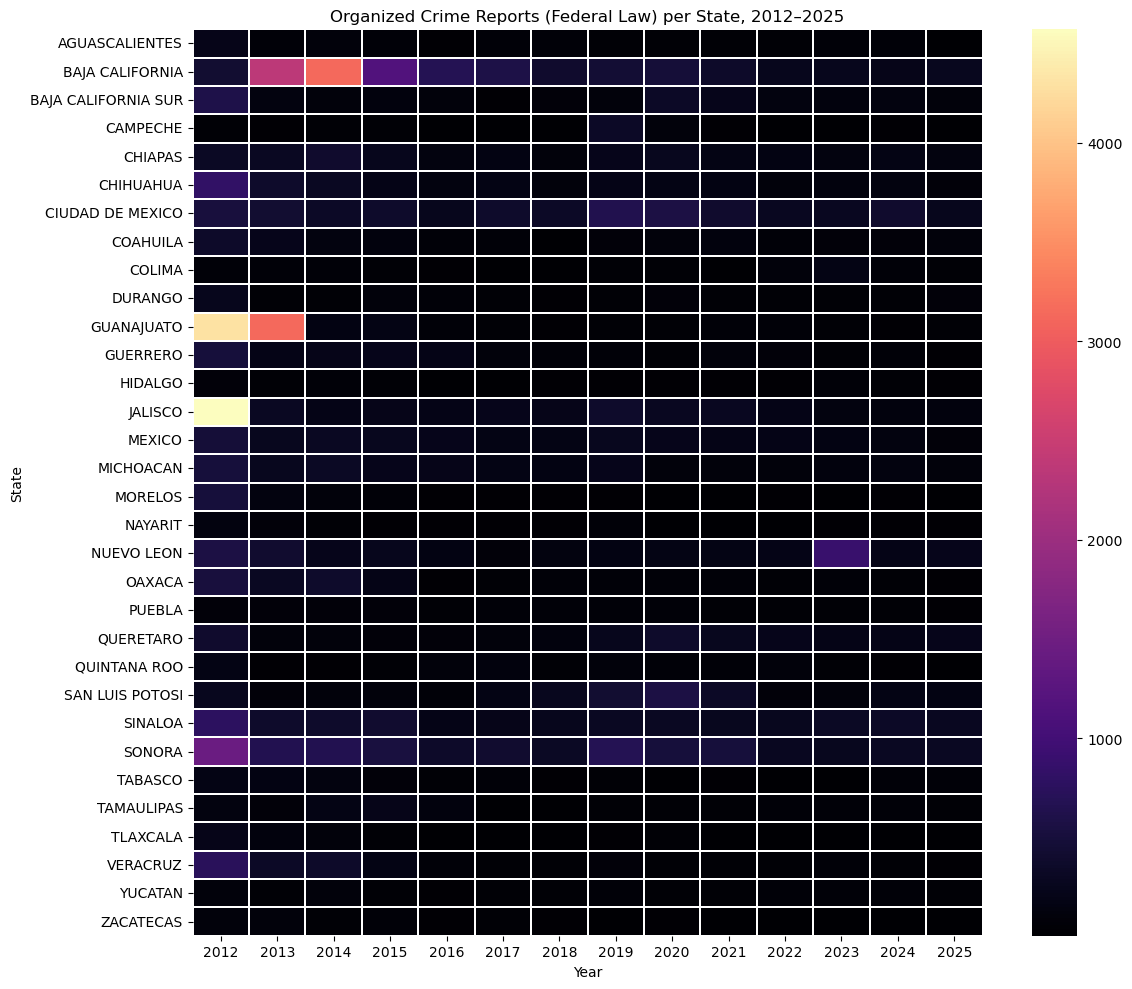

In [37]:
heat_data = df_do_yearly.pivot(index='entidad', columns='ao', values='conteo_delitos').fillna(0)

plt.figure(figsize=(12,10))
sns.heatmap(heat_data, cmap='magma', linewidths=0.3)
plt.title('Organized Crime Reports (Federal Law) per State, 2012–2025')
plt.xlabel('Year')
plt.ylabel('State')
plt.tight_layout()
plt.show()

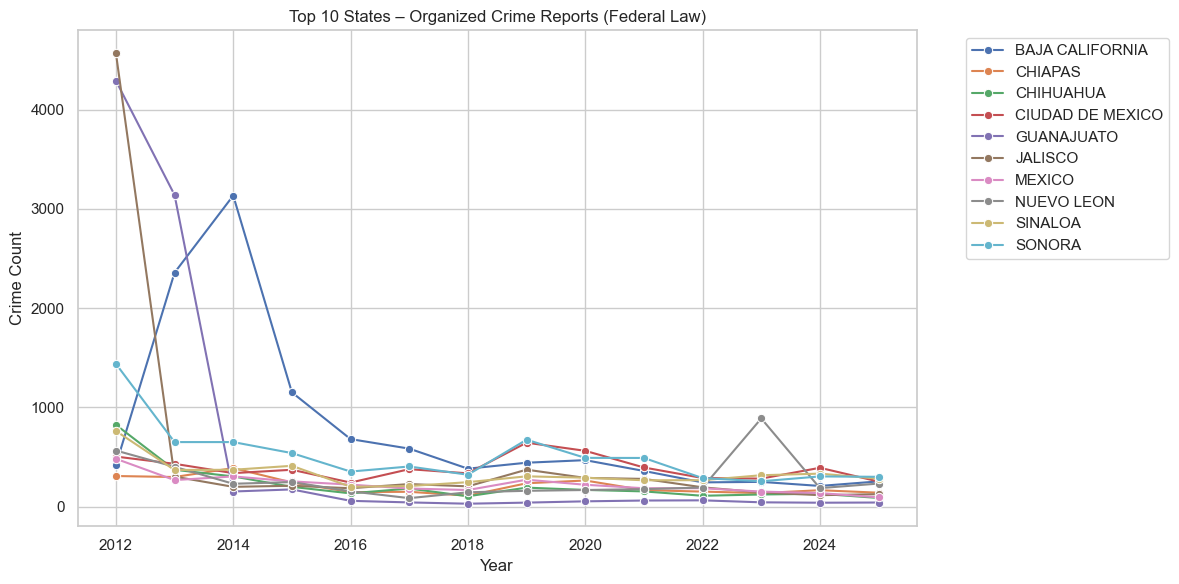

In [38]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_top10_do,
    x='ao',
    y='conteo_delitos',
    hue='entidad',
    marker='o'
)
plt.title('Top 10 States – Organized Crime Reports (Federal Law)')
plt.xlabel('Year')
plt.ylabel('Crime Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


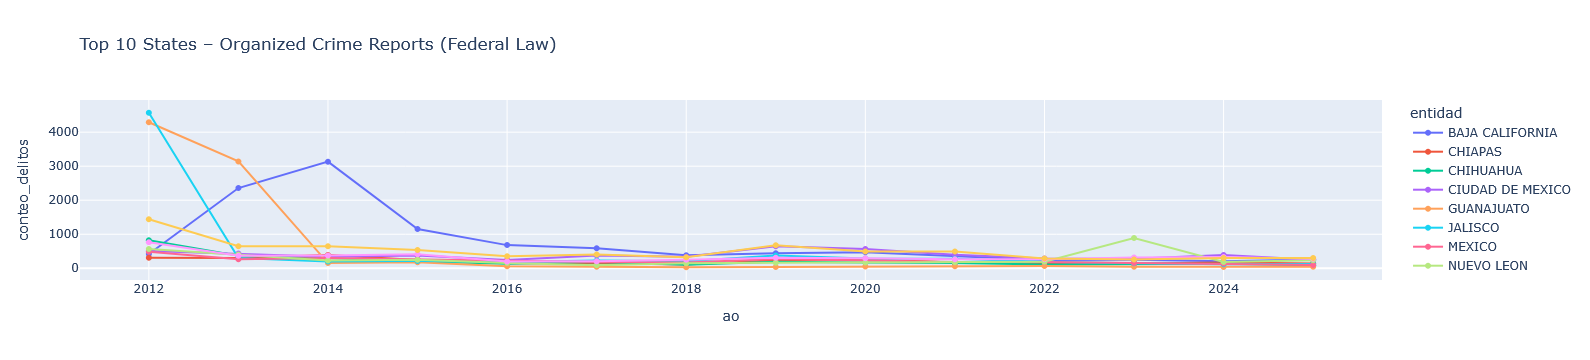

In [39]:
# Create interactive plot

fig = px.line(
    df_top10_do,
    x='ao',
    y='conteo_delitos',
    color='entidad',
    markers=True,
    title='Top 10 States – Organized Crime Reports (Federal Law)'
)
fig.update_layout(hovermode='x unified')
fig.show()


### Rates per 100k inhabitants

In [40]:
df_do_rates = df_do_yearly.merge(df_pop_yearly.loc[:, ['ao', 'cve_geo', 'poblacion']], on=['cve_geo', 'ao'])
df_do_rates.head(10)

,entidad,ao,cve_geo,conteo_delitos,poblacion
0,AGUASCALIENTES,2012,1,205.0,1265972
1,AGUASCALIENTES,2013,1,75.0,1293332
2,AGUASCALIENTES,2014,1,98.0,1320036
3,AGUASCALIENTES,2015,1,61.0,1344649
4,AGUASCALIENTES,2016,1,25.0,1367412
5,AGUASCALIENTES,2017,1,59.0,1389971
6,AGUASCALIENTES,2018,1,58.0,1413003
7,AGUASCALIENTES,2019,1,44.0,1436338
8,AGUASCALIENTES,2020,1,57.0,1456050
9,AGUASCALIENTES,2021,1,44.0,1472645


In [41]:
df_do_rates['tasa_por_100k'] = df_do_rates['conteo_delitos'] / df_do_rates['poblacion'] * 100000
df_do_rates.head()

,entidad,ao,cve_geo,conteo_delitos,poblacion,tasa_por_100k
0,AGUASCALIENTES,2012,1,205.0,1265972,16.193091
1,AGUASCALIENTES,2013,1,75.0,1293332,5.798975
2,AGUASCALIENTES,2014,1,98.0,1320036,7.424040
3,AGUASCALIENTES,2015,1,61.0,1344649,4.536500
4,AGUASCALIENTES,2016,1,25.0,1367412,1.828271


In [42]:
top10_rates_do = df_do_rates.groupby('entidad')['tasa_por_100k'].sum().nlargest(10).index
df_top10_rates_do = df_do_rates[df_do_rates['entidad'].isin(top10_rates_do)]
df_top10_rates_do.entidad.unique()

array(['BAJA CALIFORNIA', 'BAJA CALIFORNIA SUR', 'CHIHUAHUA', 'COLIMA',
       'GUANAJUATO', 'JALISCO', 'QUERETARO', 'SAN LUIS POTOSI', 'SINALOA',
       'SONORA'], dtype=object)

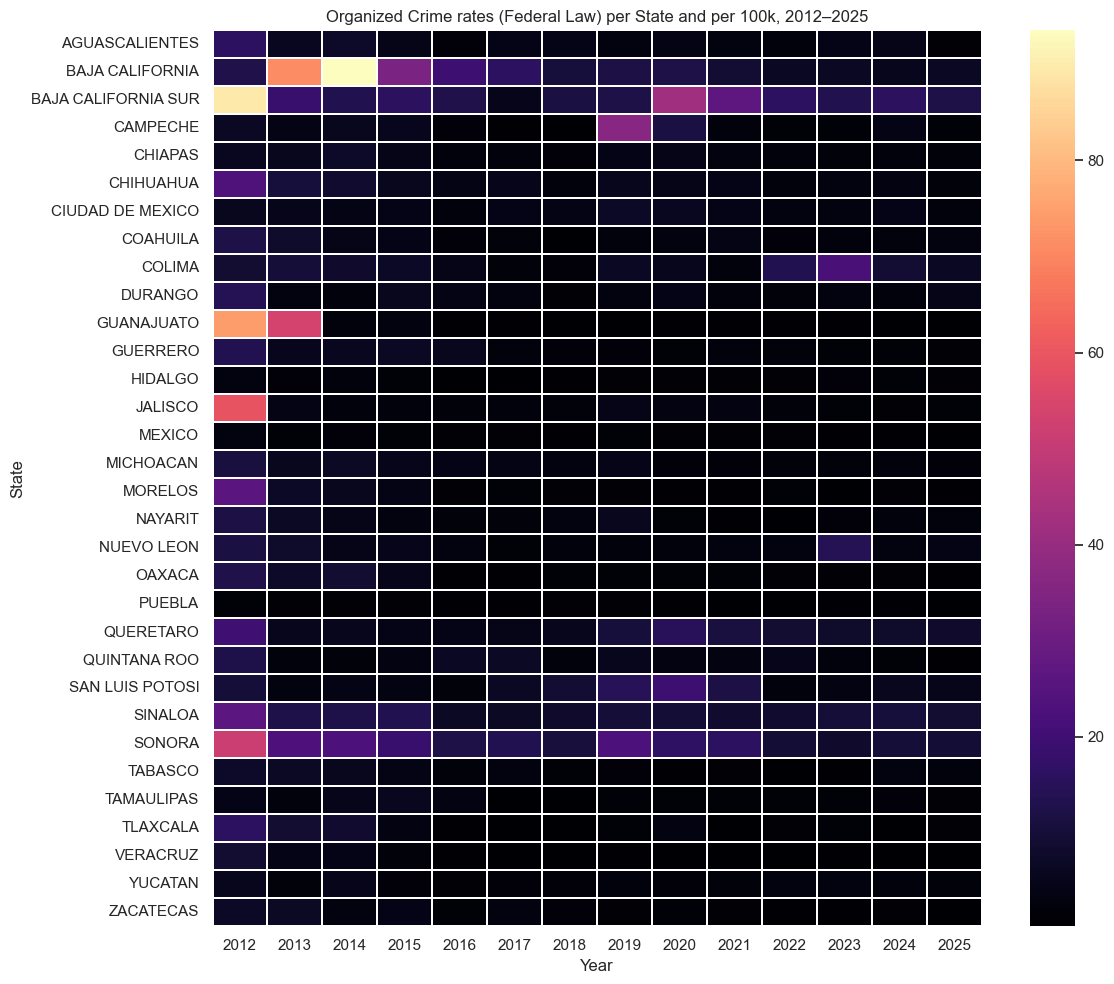

In [43]:
heat_data = df_do_rates.pivot(index='entidad', columns='ao', values='tasa_por_100k').fillna(0)

plt.figure(figsize=(12,10))
sns.heatmap(heat_data, cmap='magma', linewidths=0.3)
plt.title('Organized Crime rates (Federal Law) per State and per 100k, 2012–2025')
plt.xlabel('Year')
plt.ylabel('State')
plt.tight_layout()
plt.show()

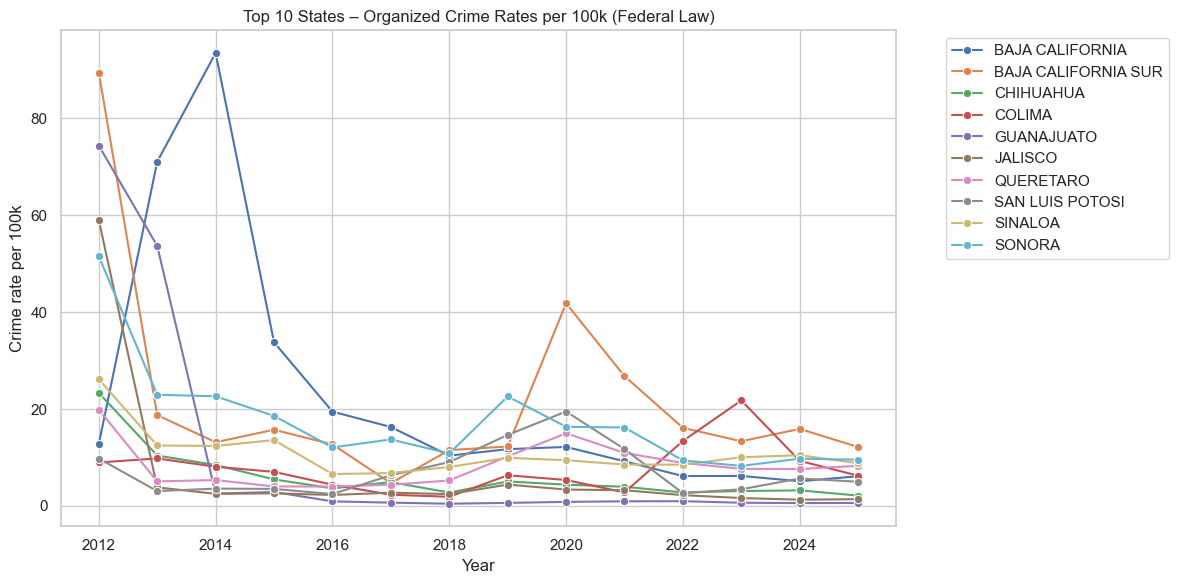

In [44]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_top10_rates_do,
    x='ao',
    y='tasa_por_100k',
    hue='entidad',
    marker='o'
)
plt.title('Top 10 States – Organized Crime Rates per 100k (Federal Law)')
plt.xlabel('Year')
plt.ylabel('Crime rate per 100k')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


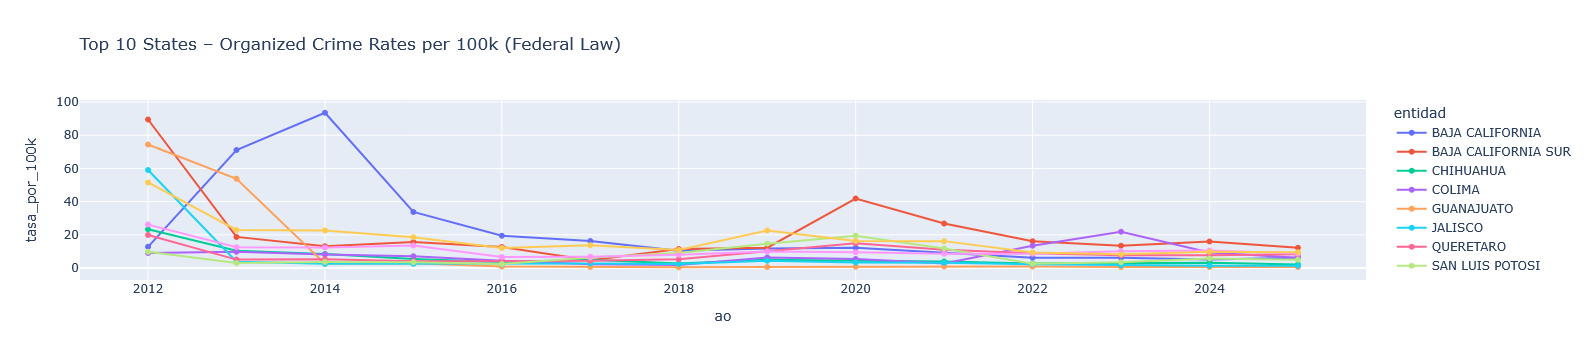

In [45]:
# Create interactive plot

fig = px.line(
    df_top10_rates_do,
    x='ao',
    y='tasa_por_100k',
    color='entidad',
    markers=True,
    title='Top 10 States – Organized Crime Rates per 100k (Federal Law)'
)
fig.update_layout(hovermode='x unified')
fig.show()


## Crime Reports (common law) - states

In [46]:
for i in range(0, 7):
    col = data_fc_melt.columns[i]
    print(col)
    print(data_fc_melt[col].unique(), '\n')

ao
[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025] 

cve_geo
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32] 

entidad
['Aguascalientes' 'Baja California' 'Baja California Sur' 'Campeche'
 'Coahuila de Zaragoza' 'Colima' 'Chiapas' 'Chihuahua' 'Ciudad de México'
 'Durango' 'Guanajuato' 'Guerrero' 'Hidalgo' 'Jalisco' 'México'
 'Michoacán de Ocampo' 'Morelos' 'Nayarit' 'Nuevo León' 'Oaxaca' 'Puebla'
 'Querétaro' 'Quintana Roo' 'San Luis Potosí' 'Sinaloa' 'Sonora' 'Tabasco'
 'Tamaulipas' 'Tlaxcala' 'Veracruz de Ignacio de la Llave' 'Yucatán'
 'Zacatecas'] 

bien_juri_afec
['La vida y la Integridad corporal' 'Libertad personal'
 'La libertad y la seguridad sexual' 'El patrimonio' 'La familia'
 'La sociedad' 'Otros bienes jurídicos afectados (del fuero común)'] 

tipo_delito
['Homicidio' 'Lesiones' 'Feminicidio' 'Aborto'
 'Otros delitos que atentan contra la vida y la integridad corporal'
 'Secuestro' 'Tráfico de menores' 'Rapto'
 '

In [47]:
oc_type_crime = ['Homicidio', 'Secuestro', 'Extorsión', 'Trata de personas', 'Narcomenudeo']
oc_subtype_crime = ['Homicidio doloso', 'Secuestro', 'Extorsión', 'Trata de personas', 'Narcomenudeo'] 

data_fc_filtered = data_fc_melt[(data_fc_melt.tipo_delito.isin(oc_type_crime)) & (data_fc_melt.subtipo_delito.isin(oc_subtype_crime))]

for i in range(3, 7):
    col = data_fc_filtered.columns[i]
    print(col)
    print(data_fc_filtered[col].unique(), '\n')

bien_juri_afec
['La vida y la Integridad corporal' 'Libertad personal' 'El patrimonio'
 'La sociedad' 'Otros bienes jurídicos afectados (del fuero común)'] 

tipo_delito
['Homicidio' 'Secuestro' 'Extorsión' 'Trata de personas' 'Narcomenudeo'] 

subtipo_delito
['Homicidio doloso' 'Secuestro' 'Extorsión' 'Trata de personas'
 'Narcomenudeo'] 

modalidad
['Con arma de fuego' 'Con arma blanca' 'Con otro elemento'
 'No especificado' 'Secuestro extorsivo' 'Secuestro con calidad de rehén'
 'Secuestro para causar daño' 'Secuestro exprés' 'Otro tipo de secuestros'
 'Extorsión' 'Trata de personas' 'Narcomenudeo'] 



In [48]:
data_fc_filtered.head()

,ao,cve_geo,entidad,bien_juri_afec,tipo_delito,subtipo_delito,modalidad,mes,conteo_delitos
0,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,enero,3.0
1,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,enero,1.0
2,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,enero,0.0
3,2015,1,Aguascalientes,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,enero,2.0
24,2015,1,Aguascalientes,Libertad personal,Secuestro,Secuestro,Secuestro extorsivo,enero,0.0


In [49]:
df_fc_yearly = data_fc_filtered.groupby(['entidad', 'ao', 'cve_geo'], as_index=False)['conteo_delitos'].sum()
df_fc_yearly.head()

,entidad,ao,cve_geo,conteo_delitos
0,Aguascalientes,2015,1,698.0
1,Aguascalientes,2016,1,830.0
2,Aguascalientes,2017,1,1052.0
3,Aguascalientes,2018,1,1941.0
4,Aguascalientes,2019,1,2428.0


### Counts

In [50]:
top10_fc = df_fc_yearly.groupby('entidad')['conteo_delitos'].sum().nlargest(10).index
df_top10_fc = df_fc_yearly[df_fc_yearly['entidad'].isin(top10_fc)]
df_top10_fc.entidad.unique()

array(['Baja California', 'Chihuahua', 'Ciudad de México',
       'Coahuila de Zaragoza', 'Guanajuato', 'Jalisco',
       'Michoacán de Ocampo', 'México', 'Nuevo León', 'Sonora'],
      dtype=object)

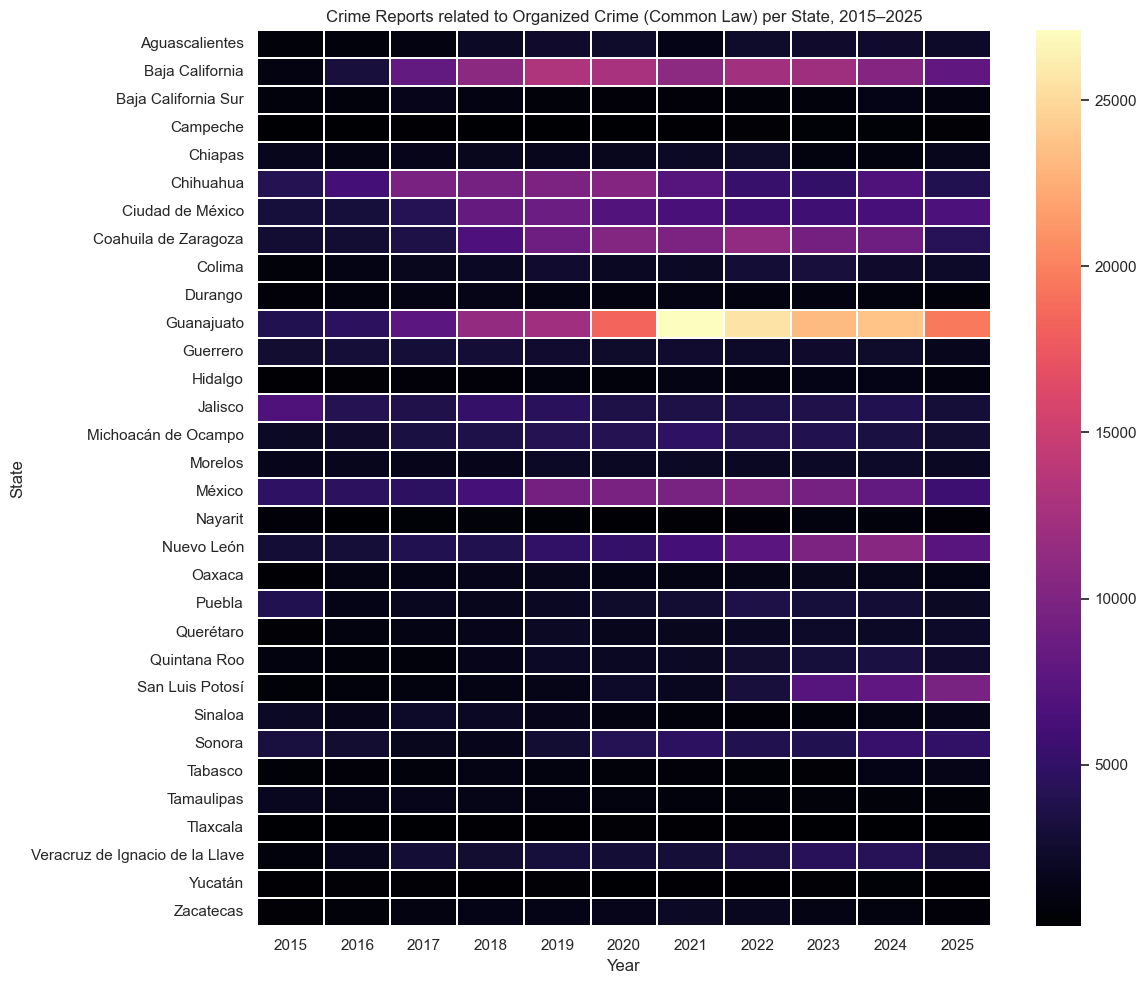

In [51]:
heat_data = df_fc_yearly.pivot(index='entidad', columns='ao', values='conteo_delitos').fillna(0)

plt.figure(figsize=(12,10))
sns.heatmap(heat_data, cmap='magma', linewidths=0.3)
plt.title('Crime Reports related to Organized Crime (Common Law) per State, 2015–2025')
plt.xlabel('Year')
plt.ylabel('State')
plt.tight_layout()
plt.show()

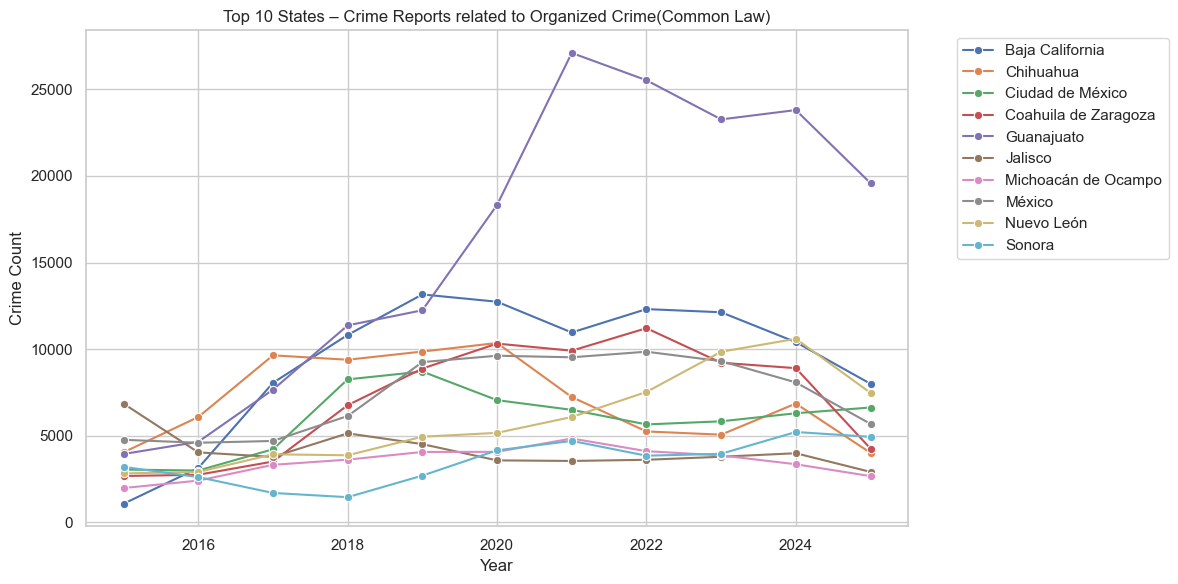

In [52]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_top10_fc,
    x='ao',
    y='conteo_delitos',
    hue='entidad',
    marker='o'
)
plt.title('Top 10 States – Crime Reports related to Organized Crime(Common Law)')
plt.xlabel('Year')
plt.ylabel('Crime Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


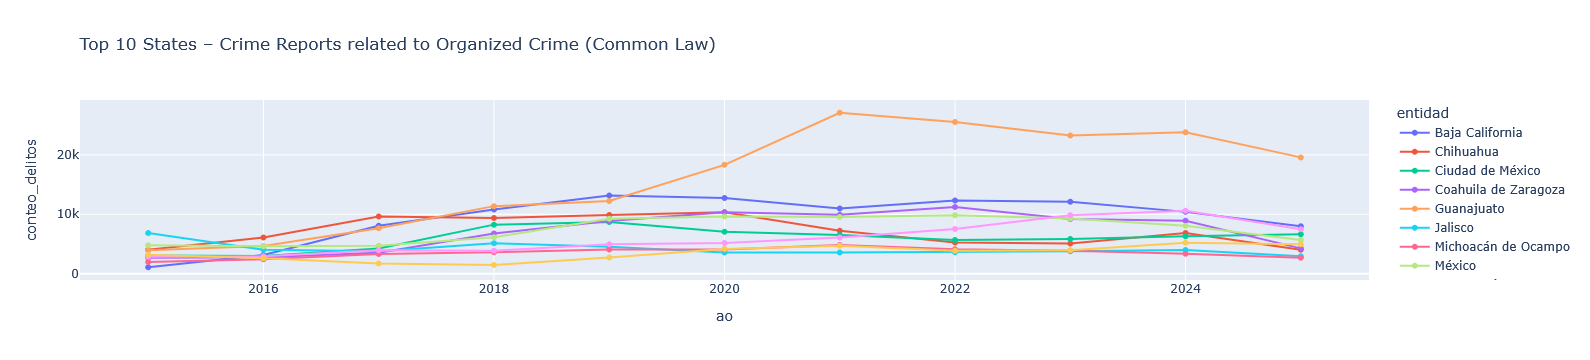

In [53]:
# Create interactive plot

fig = px.line(
    df_top10_fc,
    x='ao',
    y='conteo_delitos',
    color='entidad',
    markers=True,
    title='Top 10 States – Crime Reports related to Organized Crime (Common Law)'
)
fig.update_layout(hovermode='x unified')
fig.show()


### Rates per 100k inhabitants

In [54]:
df_fc_rates = df_fc_yearly.merge(df_pop_yearly.loc[:, ['ao', 'cve_geo', 'poblacion']], on=['cve_geo', 'ao'])
df_fc_rates.head(10)

,entidad,ao,cve_geo,conteo_delitos,poblacion
0,Aguascalientes,2015,1,698.0,1344649
1,Aguascalientes,2016,1,830.0,1367412
2,Aguascalientes,2017,1,1052.0,1389971
3,Aguascalientes,2018,1,1941.0,1413003
4,Aguascalientes,2019,1,2428.0,1436338
5,Aguascalientes,2020,1,2289.0,1456050
6,Aguascalientes,2021,1,1284.0,1472645
7,Aguascalientes,2022,1,2255.0,1491126
8,Aguascalientes,2023,1,2376.0,1510839
9,Aguascalientes,2024,1,2407.0,1530185


In [55]:
df_fc_rates['tasa_por_100k'] = df_fc_rates['conteo_delitos'] / df_fc_rates['poblacion'] * 100000
df_fc_rates.head()

,entidad,ao,cve_geo,conteo_delitos,poblacion,tasa_por_100k
0,Aguascalientes,2015,1,698.0,1344649,51.909457
1,Aguascalientes,2016,1,830.0,1367412,60.698604
2,Aguascalientes,2017,1,1052.0,1389971,75.685032
3,Aguascalientes,2018,1,1941.0,1413003,137.367012
4,Aguascalientes,2019,1,2428.0,1436338,169.040992


In [56]:
top10_rates_fc= df_fc_rates.groupby('entidad')['tasa_por_100k'].sum().nlargest(10).index
df_top10_rates_fc = df_fc_rates[df_fc_rates['entidad'].isin(top10_rates_fc)]
df_top10_rates_fc.entidad.unique()

array(['Aguascalientes', 'Baja California', 'Baja California Sur',
       'Chihuahua', 'Coahuila de Zaragoza', 'Colima', 'Guanajuato',
       'Quintana Roo', 'San Luis Potosí', 'Sonora'], dtype=object)

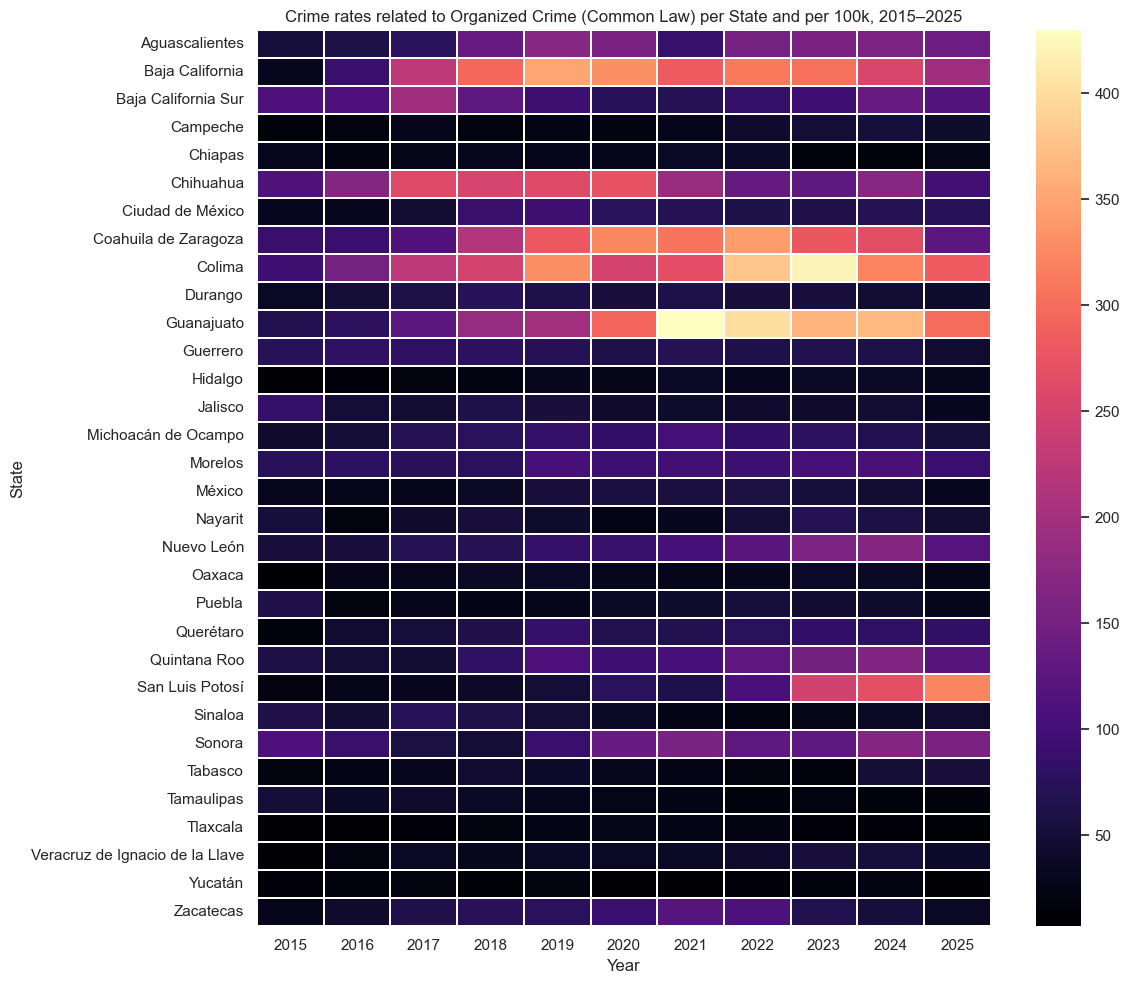

In [57]:
heat_data = df_fc_rates.pivot(index='entidad', columns='ao', values='tasa_por_100k').fillna(0)

plt.figure(figsize=(12,10))
sns.heatmap(heat_data, cmap='magma', linewidths=0.3)
plt.title('Crime rates related to Organized Crime (Common Law) per State and per 100k, 2015–2025')
plt.xlabel('Year')
plt.ylabel('State')
plt.tight_layout()
plt.show()

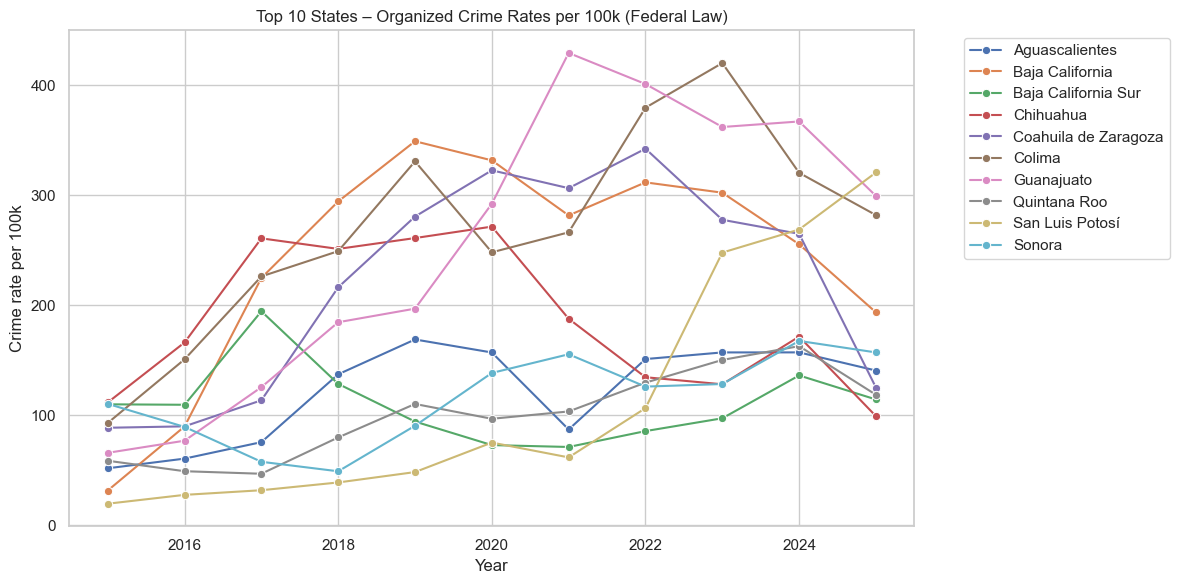

In [58]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_top10_rates_fc,
    x='ao',
    y='tasa_por_100k',
    hue='entidad',
    marker='o'
)
plt.title('Top 10 States – Organized Crime Rates per 100k (Federal Law)')
plt.xlabel('Year')
plt.ylabel('Crime rate per 100k')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


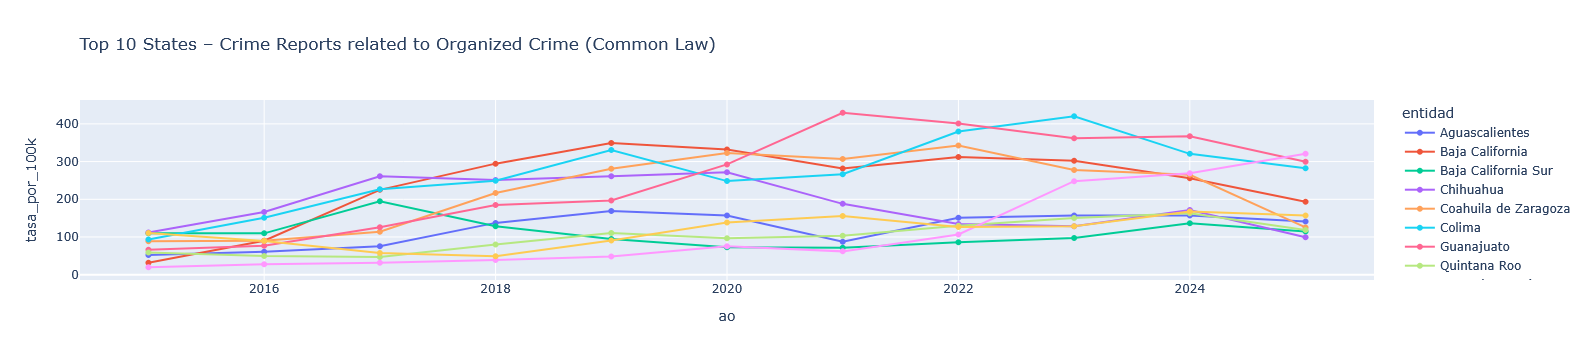

In [59]:
# Create interactive plot

fig = px.line(
    df_top10_rates_fc,
    x='ao',
    y='tasa_por_100k',
    color='entidad',
    markers=True,
    title='Top 10 States – Crime Reports related to Organized Crime (Common Law)'
)
fig.update_layout(hovermode='x unified')
fig.show()


## Comparison between federal and common law crime reports (by states)

In [66]:
merged = df_do_rates.merge(df_fc_rates, on=['cve_geo','ao'], suffixes=('_fed','_com'))
merged.head()

,entidad_fed,ao,cve_geo,conteo_delitos_fed,poblacion_fed,tasa_por_100k_fed,entidad_com,conteo_delitos_com,poblacion_com,tasa_por_100k_com
0,AGUASCALIENTES,2015,1,61.0,1344649,4.536500,Aguascalientes,698.0,1344649,51.909457
1,AGUASCALIENTES,2016,1,25.0,1367412,1.828271,Aguascalientes,830.0,1367412,60.698604
2,AGUASCALIENTES,2017,1,59.0,1389971,4.244693,Aguascalientes,1052.0,1389971,75.685032
3,AGUASCALIENTES,2018,1,58.0,1413003,4.104733,Aguascalientes,1941.0,1413003,137.367012
4,AGUASCALIENTES,2019,1,44.0,1436338,3.063346,Aguascalientes,2428.0,1436338,169.040992


C:\Users\penny\AppData\Local\Temp\ipykernel_26064\2384757371.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




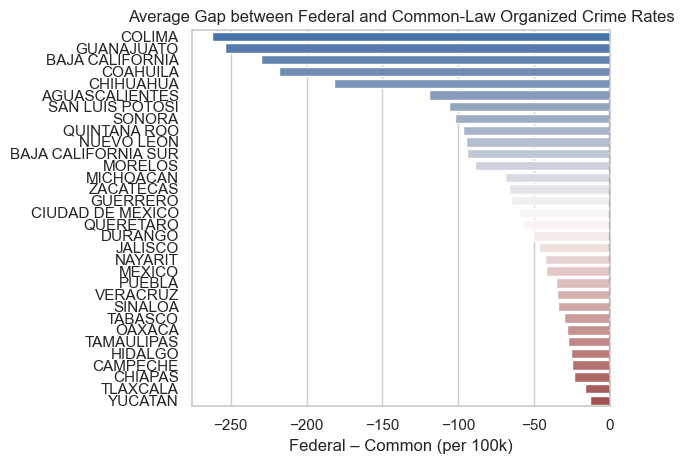

In [67]:
merged['diferencia'] = merged['tasa_por_100k_fed'] - merged['tasa_por_100k_com']
gap_df = merged.groupby('entidad_fed')['diferencia'].mean().reset_index()

sns.barplot(data=gap_df.sort_values('diferencia'), y='entidad_fed', x='diferencia', palette='vlag')
plt.axvline(0, color='black', linestyle='--')
plt.title('Average Gap between Federal and Common-Law Organized Crime Rates')
plt.xlabel('Federal – Common (per 100k)')
plt.ylabel('')
plt.tight_layout()
plt.show()


## Crime reports (common law) - municipalities

In [68]:
for i in range(0, 9):
    col = data_cm_melt.columns[i]
    print(col)
    print(data_cm_melt[col].unique(), '\n')

ao
[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025] 

cve_geo
[12 15 16] 

entidad
['Guerrero' 'México' 'Michoacán de Ocampo'] 

cve_municipio
[12001 12002 12003 12004 12005 12006 12007 12008 12009 12010 12011 12012
 12013 12014 12015 12016 12017 12018 12019 12020 12021 12022 12023 12024
 12025 12026 12027 12028 12029 12030 12031 12032 12033 12034 12035 12036
 12037 12038 12039 12040 12041 12042 12043 12044 12045 12046 12047 12048
 12049 12050 12051 12052 12053 12054 12055 12056 12057 12058 12059 12060
 12061 12062 12063 12064 12065 12066 12067 12068 12069 12070 12071 12072
 12073 12074 12075 12076 12077 12078 12079 12080 12081 15001 15002 15003
 15004 15005 15006 15007 15008 15009 15010 15011 15012 15013 15014 15015
 15016 15017 15018 15019 15020 15021 15022 15023 15024 15025 15026 15027
 15028 15029 15030 15031 15032 15033 15034 15035 15036 15037 15038 15039
 15040 15041 15042 15043 15044 15045 15046 15047 15048 15049 15050 15051
 15052 15053 15054 15055 15056 15057 15058 150

In [69]:
oc_type_crime = ['Homicidio', 'Secuestro', 'Extorsión', 'Trata de personas', 'Narcomenudeo']
oc_subtype_crime = ['Homicidio doloso', 'Secuestro', 'Extorsión', 'Trata de personas', 'Narcomenudeo'] 

data_cm_filtered = data_cm_melt[(data_cm_melt.tipo_delito.isin(oc_type_crime)) & (data_cm_melt.subtipo_delito.isin(oc_subtype_crime))]

for i in range(5, 9):
    col = data_cm_filtered.columns[i]
    print(col)
    print(data_cm_filtered[col].unique(), '\n')

bien_juri_afec
['La vida y la Integridad corporal' 'Libertad personal' 'El patrimonio'
 'La sociedad' 'Otros bienes jurídicos afectados (del fuero común)'] 

tipo_delito
['Homicidio' 'Secuestro' 'Extorsión' 'Trata de personas' 'Narcomenudeo'] 

subtipo_delito
['Homicidio doloso' 'Secuestro' 'Extorsión' 'Trata de personas'
 'Narcomenudeo'] 

modalidad
['Con arma de fuego' 'Con arma blanca' 'Con otro elemento'
 'No especificado' 'Secuestro extorsivo' 'Secuestro con calidad de rehén'
 'Secuestro para causar daño' 'Secuestro exprés' 'Otro tipo de secuestros'
 'Extorsión' 'Trata de personas' 'Narcomenudeo'] 



In [70]:
data_cm_filtered.head()

,ao,cve_geo,entidad,cve_municipio,municipio,bien_juri_afec,tipo_delito,subtipo_delito,modalidad,mes,conteo_delitos
0,2015,12,Guerrero,12001,Acapulco de Juárez,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma de fuego,enero,29.0
1,2015,12,Guerrero,12001,Acapulco de Juárez,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con arma blanca,enero,1.0
2,2015,12,Guerrero,12001,Acapulco de Juárez,La vida y la Integridad corporal,Homicidio,Homicidio doloso,Con otro elemento,enero,5.0
3,2015,12,Guerrero,12001,Acapulco de Juárez,La vida y la Integridad corporal,Homicidio,Homicidio doloso,No especificado,enero,0.0
24,2015,12,Guerrero,12001,Acapulco de Juárez,Libertad personal,Secuestro,Secuestro,Secuestro extorsivo,enero,0.0


In [71]:
df_cm_yearly = data_cm_filtered.groupby(['ao', 'cve_geo', 'entidad', 'cve_municipio', 'municipio'], as_index=False)['conteo_delitos'].sum()
df_cm_yearly.head()

,ao,cve_geo,entidad,cve_municipio,municipio,conteo_delitos
0,2015,12,Guerrero,12001,Acapulco de Juárez,1158.0
1,2015,12,Guerrero,12002,Ahuacuotzingo,0.0
2,2015,12,Guerrero,12003,Ajuchitlán del Progreso,19.0
3,2015,12,Guerrero,12004,Alcozauca de Guerrero,8.0
4,2015,12,Guerrero,12005,Alpoyeca,3.0


### Counts

In [72]:
top30_cm = df_cm_yearly.groupby('municipio')['conteo_delitos'].sum().nlargest(30).index
df_top30_cm = df_cm_yearly[df_cm_yearly['municipio'].isin(top30_cm)]
df_top30_cm.municipio.unique()

array(['Acapulco de Juárez', 'Chilpancingo de los Bravo',
       'Iguala de la Independencia', 'Zihuatanejo de Azueta',
       'Atizapán de Zaragoza', 'Chalco', 'Chimalhuacán',
       'Ecatepec de Morelos', 'Huixquilucan', 'Ixtapaluca', 'Metepec',
       'Naucalpan de Juárez', 'Nezahualcóyotl', 'Nicolás Romero',
       'La Paz', 'Tecámac', 'Texcoco', 'Tlalnepantla de Baz', 'Toluca',
       'Tultitlán', 'Zumpango', 'Cuautitlán Izcalli',
       'Valle de Chalco Solidaridad', 'Apatzingán', 'Jacona',
       'Lázaro Cárdenas', 'Morelia', 'Uruapan', 'Zamora', 'Zitácuaro'],
      dtype=object)

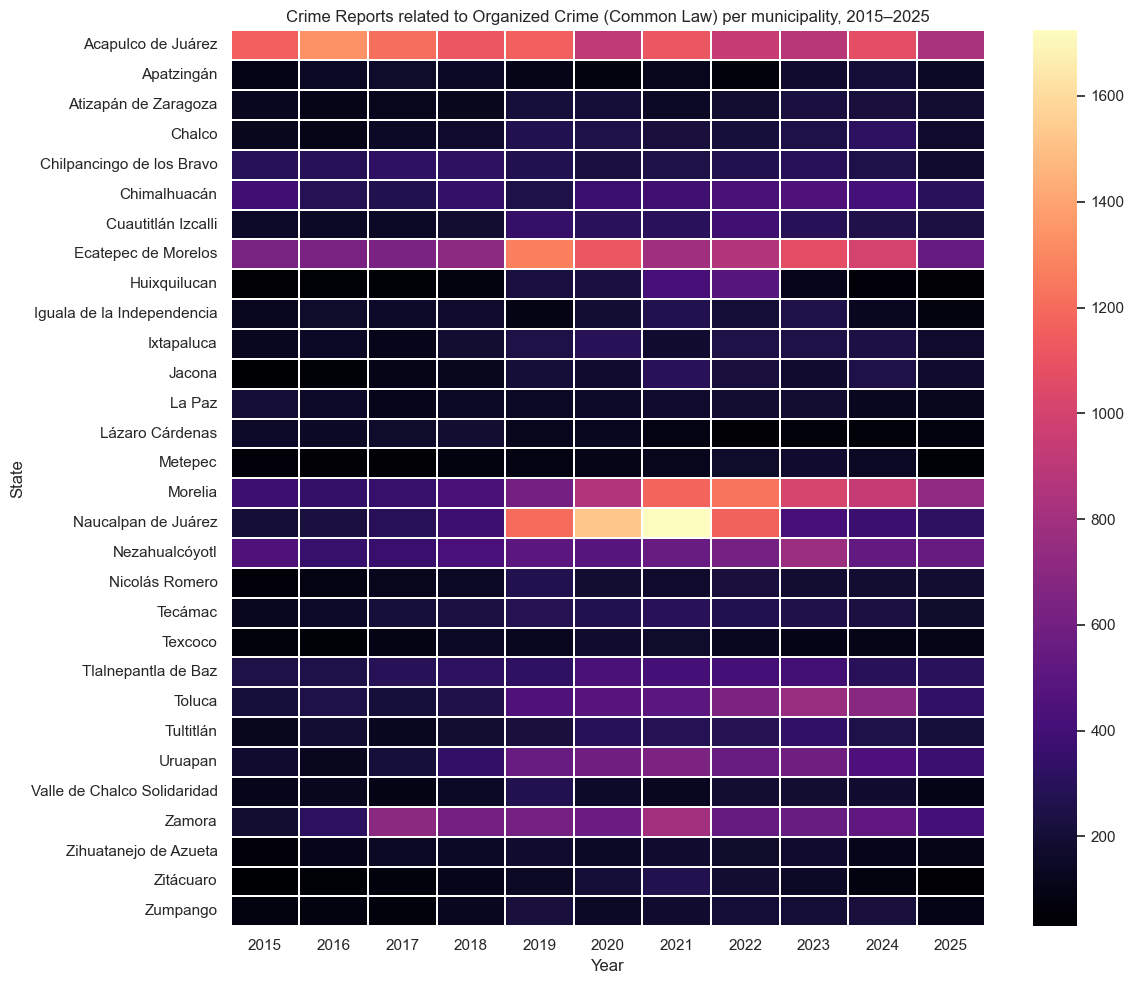

In [73]:
df_cm_yearly_f = df_cm_yearly[df_cm_yearly.municipio.isin(df_top30_cm.municipio.unique())]
heat_data = df_cm_yearly_f.pivot(index='municipio', columns='ao', values='conteo_delitos').fillna(0)

plt.figure(figsize=(12,10))
sns.heatmap(heat_data, cmap='magma', linewidths=0.3)
plt.title('Crime Reports related to Organized Crime (Common Law) per municipality, 2015–2025')
plt.xlabel('Year')
plt.ylabel('State')
plt.tight_layout()
plt.show()

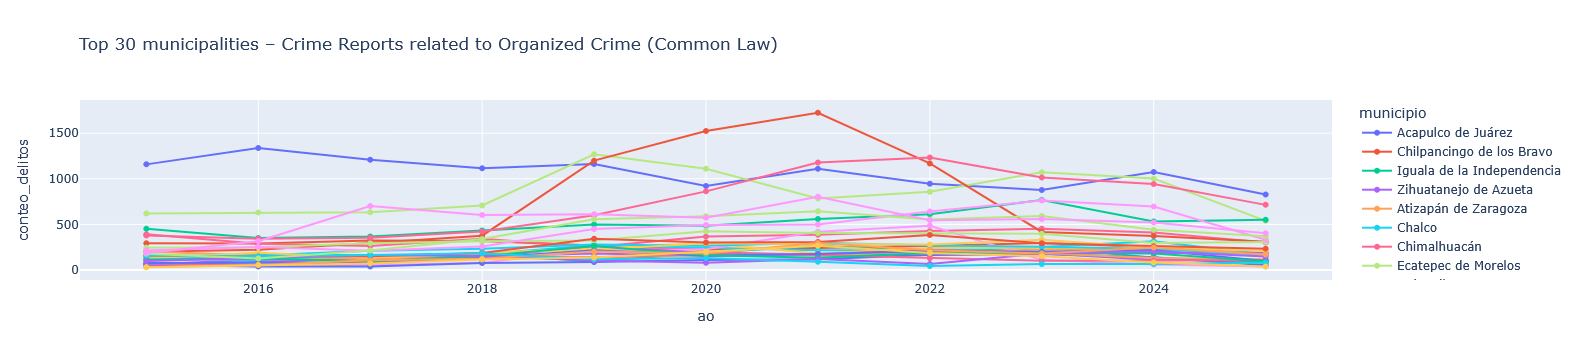

In [74]:
# Create interactive plot

fig = px.line(
    df_top30_cm,
    x='ao',
    y='conteo_delitos',
    color='municipio',
    markers=True,
    title='Top 30 municipalities – Crime Reports related to Organized Crime (Common Law)'
)
fig.update_layout(hovermode='x unified')
fig.show()


### Rates per 100k inhabitants

In [83]:
df_cm_yearly.rename(columns={'ao': 'year', 'cve_geo': 'state_id', 'entidad': 'state', 
                             'cve_municipio': 'muni_id', 'municipio': 'municipality', 
                             'conteo_delitos': 'crime_counts'}, inplace=True)

df_cm_yearly.head()

,year,state_id,state,muni_id,municipality,crime_counts
0,2015,12,Guerrero,12001,Acapulco de Juárez,1158.0
1,2015,12,Guerrero,12002,Ahuacuotzingo,0.0
2,2015,12,Guerrero,12003,Ajuchitlán del Progreso,19.0
3,2015,12,Guerrero,12004,Alcozauca de Guerrero,8.0
4,2015,12,Guerrero,12005,Alpoyeca,3.0


In [84]:
df_cm_rates = df_cm_yearly.merge(df_pop_yearly_m.loc[:, ['year', 'muni_id', 'pop_total']], on=['muni_id', 'year'])
df_cm_rates.head(10)

,year,state_id,state,muni_id,municipality,crime_counts,pop_total
0,2015,12,Guerrero,12001,Acapulco de Juárez,1158.0,828751
1,2015,12,Guerrero,12002,Ahuacuotzingo,0.0,27414
2,2015,12,Guerrero,12003,Ajuchitlán del Progreso,19.0,39048
3,2015,12,Guerrero,12004,Alcozauca de Guerrero,8.0,19960
4,2015,12,Guerrero,12005,Alpoyeca,3.0,6885
5,2015,12,Guerrero,12006,Apaxtla,2.0,11431
6,2015,12,Guerrero,12007,Arcelia,36.0,32287
7,2015,12,Guerrero,12008,Atenango del Río,4.0,8971
8,2015,12,Guerrero,12009,Atlamajalcingo del Monte,0.0,5630
9,2015,12,Guerrero,12010,Atlixtac,1.0,27964


In [85]:
df_cm_rates['rate_100k'] = df_cm_rates['crime_counts'] / df_cm_rates['pop_total'] * 100000
df_cm_rates.head()

,year,state_id,state,muni_id,municipality,crime_counts,pop_total,rate_100k
0,2015,12,Guerrero,12001,Acapulco de Juárez,1158.0,828751,139.728338
1,2015,12,Guerrero,12002,Ahuacuotzingo,0.0,27414,0.000000
2,2015,12,Guerrero,12003,Ajuchitlán del Progreso,19.0,39048,48.658062
3,2015,12,Guerrero,12004,Alcozauca de Guerrero,8.0,19960,40.080160
4,2015,12,Guerrero,12005,Alpoyeca,3.0,6885,43.572985


In [87]:
top30_rates_cm= df_cm_rates.groupby('municipality')['rate_100k'].sum().nlargest(30).index
df_top30_rates_cm = df_cm_rates[df_cm_rates['municipality'].isin(top30_rates_cm)]
df_top30_rates_cm.municipality.unique()

array(['Acapulco de Juárez', 'Coyuca de Benítez',
       'Chilpancingo de los Bravo', 'Iguala de la Independencia',
       'Zihuatanejo de Azueta', 'Axapusco', 'Coyotepec',
       'Ixtapan de la Sal', 'Malinalco', 'Naucalpan de Juárez',
       'Teoloyucan', 'Apatzingán', 'Buenavista', 'Copándaro', 'Cotija',
       'Charo', 'Chavinda', 'Jacona', 'Jiquilpan', 'Lagunillas',
       'Morelia', 'La Piedad', 'Purépero', 'Puruándiro', 'Sahuayo',
       'Tangancícuaro', 'Uruapan', 'Venustiano Carranza', 'Zamora',
       'Zitácuaro'], dtype=object)

In [89]:
df_top30_rates_cm[df_top30_rates_cm.municipality == 'Jacona']

,year,state_id,state,muni_id,municipality,crime_counts,pop_total,rate_100k
248,2015,16,Michoacán de Ocampo,16043,Jacona,34.0,71057,47.848910
567,2016,16,Michoacán de Ocampo,16043,Jacona,55.0,70812,77.670451
886,2017,16,Michoacán de Ocampo,16043,Jacona,107.0,70535,151.697739
1205,2018,16,Michoacán de Ocampo,16043,Jacona,124.0,70278,176.442130
1524,2019,16,Michoacán de Ocampo,16043,Jacona,203.0,70013,289.946153
1843,2020,16,Michoacán de Ocampo,16043,Jacona,181.0,69746,259.513090
2162,2021,16,Michoacán de Ocampo,16043,Jacona,297.0,69649,426.423926
2481,2022,16,Michoacán de Ocampo,16043,Jacona,217.0,69636,311.620426
2804,2023,16,Michoacán de Ocampo,16043,Jacona,181.0,69760,259.461009
3127,2024,16,Michoacán de Ocampo,16043,Jacona,247.0,69858,353.574394


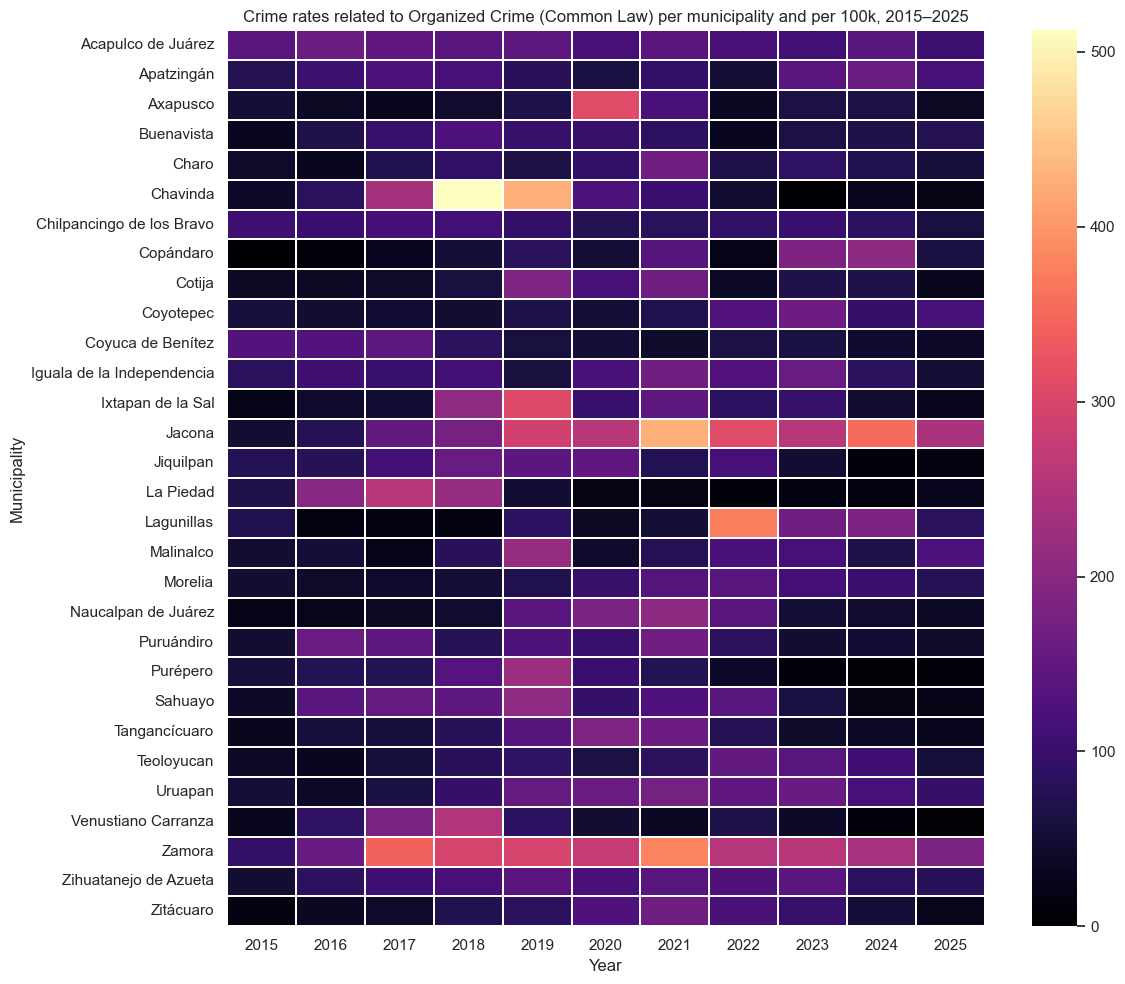

In [90]:
heat_data = df_top30_rates_cm.pivot(index='municipality', columns='year', values='rate_100k').fillna(0)

plt.figure(figsize=(12,10))
sns.heatmap(heat_data, cmap='magma', linewidths=0.3)
plt.title('Crime rates related to Organized Crime (Common Law) per municipality and per 100k, 2015–2025')
plt.xlabel('Year')
plt.ylabel('Municipality')
plt.tight_layout()
plt.show()

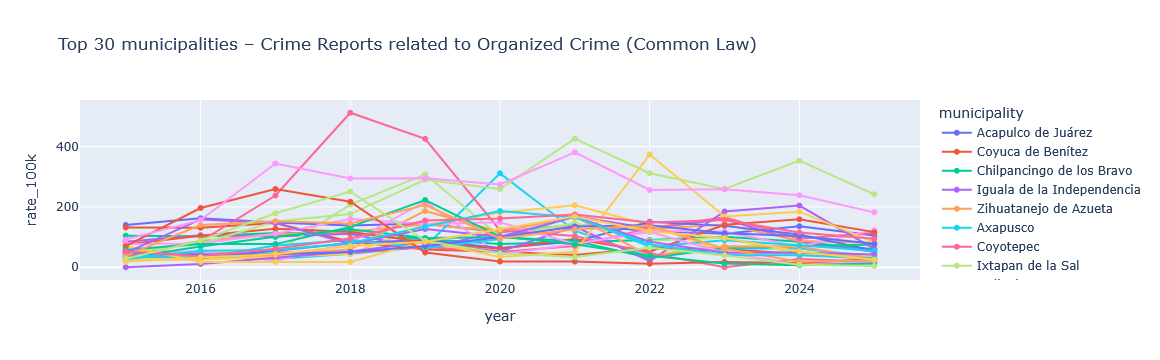

In [91]:
# Create interactive plot

fig = px.line(
    df_top30_rates_cm,
    x='year',
    y='rate_100k',
    color='municipality',
    markers=True,
    title='Top 30 municipalities – Crime Reports related to Organized Crime (Common Law)'
)
fig.update_layout(hovermode='x unified')
fig.show()


### Save data

In [92]:
df_cm_rates.to_csv(out_data_crime_mun, index=False)

## Crime panel data

In [93]:
crime_panel_melt_r[crime_panel_melt_r.year == 2025].month.unique()

array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=object)

In [94]:
oc_type_crime = ['Homicidio', 'Secuestro', 'Extorsión', 'Trata de personas', 'Narcomenudeo']
oc_subtype_crime = ['Homicidio doloso', 'Secuestro', 'Extorsión', 'Trata de personas', 'Narcomenudeo'] 

crime_panel_filtered = crime_panel_melt_r[(crime_panel_melt_r.crime_type.isin(oc_type_crime)) & (crime_panel_melt_r.crime_subtype.isin(oc_subtype_crime))]

for i in range(5, 9):
    col = crime_panel_filtered.columns[i]
    print(col)
    print(crime_panel_filtered[col].unique(), '\n')

crime_type
['Homicidio' 'Secuestro' 'Extorsión' 'Trata de personas' 'Narcomenudeo'] 

crime_subtype
['Homicidio doloso' 'Secuestro' 'Extorsión' 'Trata de personas'
 'Narcomenudeo'] 

modality
['Con arma de fuego' 'Con arma blanca' 'Con otro elemento'
 'No especificado' 'Secuestro extorsivo' 'Secuestro con calidad de rehén'
 'Secuestro para causar daño' 'Secuestro exprés' 'Otro tipo de secuestros'
 'Extorsión' 'Trata de personas' 'Narcomenudeo'] 

month
[1 2 3 4 5 6 7 8 9 10 11 12] 



In [95]:
crime_panel_filtered.drop(['crime_type', 'modality'], axis=1, inplace=True)
crime_panel_filtered.head()

C:\Users\penny\AppData\Local\Temp\ipykernel_26064\3953777101.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,year,state_id,state,muni_id,municipality,crime_subtype,month,crime_count
0,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio doloso,1,29.0
1,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio doloso,1,1.0
2,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio doloso,1,5.0
3,2015,12,Guerrero,12001,Acapulco de Juárez,Homicidio doloso,1,0.0
24,2015,12,Guerrero,12001,Acapulco de Juárez,Secuestro,1,0.0


In [96]:
crime_panel_m = crime_panel_filtered.groupby(['year', 'month', 'state_id', 'state', 'muni_id', 'municipality', 'crime_subtype'], as_index=False)['crime_count'].sum()
crime_panel_m.head(10)

,year,month,state_id,state,muni_id,municipality,crime_subtype,crime_count
0,2015,1,12,Guerrero,12001,Acapulco de Juárez,Extorsión,5.0
1,2015,1,12,Guerrero,12001,Acapulco de Juárez,Homicidio doloso,35.0
2,2015,1,12,Guerrero,12001,Acapulco de Juárez,Narcomenudeo,32.0
3,2015,1,12,Guerrero,12001,Acapulco de Juárez,Secuestro,0.0
4,2015,1,12,Guerrero,12001,Acapulco de Juárez,Trata de personas,0.0
5,2015,1,12,Guerrero,12002,Ahuacuotzingo,Extorsión,0.0
6,2015,1,12,Guerrero,12002,Ahuacuotzingo,Homicidio doloso,0.0
7,2015,1,12,Guerrero,12002,Ahuacuotzingo,Narcomenudeo,0.0
8,2015,1,12,Guerrero,12002,Ahuacuotzingo,Secuestro,0.0
9,2015,1,12,Guerrero,12002,Ahuacuotzingo,Trata de personas,0.0


In [97]:
crime_panel_rates = crime_panel_m.merge(df_pop_yearly_m.loc[:, ['year', 'muni_id', 'pop_total']], on=['muni_id', 'year'])
crime_panel_rates['crime_rate_100k'] = crime_panel_rates['crime_count'] / crime_panel_rates['pop_total'] * 100000
crime_panel_rates.head(10)

,year,month,state_id,state,muni_id,municipality,crime_subtype,crime_count,pop_total,crime_rate_100k
0,2015,1,12,Guerrero,12001,Acapulco de Juárez,Extorsión,5.0,828751,0.603318
1,2015,1,12,Guerrero,12001,Acapulco de Juárez,Homicidio doloso,35.0,828751,4.223223
2,2015,1,12,Guerrero,12001,Acapulco de Juárez,Narcomenudeo,32.0,828751,3.861232
3,2015,1,12,Guerrero,12001,Acapulco de Juárez,Secuestro,0.0,828751,0.000000
4,2015,1,12,Guerrero,12001,Acapulco de Juárez,Trata de personas,0.0,828751,0.000000
5,2015,1,12,Guerrero,12002,Ahuacuotzingo,Extorsión,0.0,27414,0.000000
6,2015,1,12,Guerrero,12002,Ahuacuotzingo,Homicidio doloso,0.0,27414,0.000000
7,2015,1,12,Guerrero,12002,Ahuacuotzingo,Narcomenudeo,0.0,27414,0.000000
8,2015,1,12,Guerrero,12002,Ahuacuotzingo,Secuestro,0.0,27414,0.000000
9,2015,1,12,Guerrero,12002,Ahuacuotzingo,Trata de personas,0.0,27414,0.000000


In [98]:
crime_panel_pivot = crime_panel_rates.pivot(index=['year', 'month', 'state_id', 'state', 'muni_id', 'municipality'], 
                                               columns = 'crime_subtype', values = 'crime_rate_100k')
crime_panel_pivot.reset_index(inplace=True)
crime_panel_pivot.head(10)

crime_subtype,year,month,state_id,state,muni_id,municipality,Extorsión,Homicidio doloso,Narcomenudeo,Secuestro,Trata de personas
0,2015,1,12,Guerrero,12001,Acapulco de Juárez,0.603318,4.223223,3.861232,0.000000,0.0
1,2015,1,12,Guerrero,12002,Ahuacuotzingo,0.000000,0.000000,0.000000,0.000000,0.0
2,2015,1,12,Guerrero,12003,Ajuchitlán del Progreso,0.000000,2.560951,0.000000,2.560951,0.0
3,2015,1,12,Guerrero,12004,Alcozauca de Guerrero,0.000000,0.000000,0.000000,0.000000,0.0
4,2015,1,12,Guerrero,12005,Alpoyeca,0.000000,14.524328,0.000000,0.000000,0.0
5,2015,1,12,Guerrero,12006,Apaxtla,0.000000,8.748141,0.000000,0.000000,0.0
6,2015,1,12,Guerrero,12007,Arcelia,0.000000,3.097222,0.000000,0.000000,0.0
7,2015,1,12,Guerrero,12008,Atenango del Río,0.000000,0.000000,0.000000,0.000000,0.0
8,2015,1,12,Guerrero,12009,Atlamajalcingo del Monte,0.000000,0.000000,0.000000,0.000000,0.0
9,2015,1,12,Guerrero,12010,Atlixtac,0.000000,0.000000,0.000000,0.000000,0.0


In [99]:
crime_panel_pivot.rename(columns={'Extorsión': 'extortion_rate', 'Homicidio doloso': 'homicide_rate', 'Narcomenudeo': 'drug_dealing_rate', 
                          'Secuestro': 'kidnapping_rate', 'Trata de personas': 'human_trafficking_rate'}, inplace=True)
crime_panel_pivot.head(10)

crime_subtype,year,month,state_id,state,muni_id,municipality,extortion_rate,homicide_rate,drug_dealing_rate,kidnapping_rate,human_trafficking_rate
0,2015,1,12,Guerrero,12001,Acapulco de Juárez,0.603318,4.223223,3.861232,0.000000,0.0
1,2015,1,12,Guerrero,12002,Ahuacuotzingo,0.000000,0.000000,0.000000,0.000000,0.0
2,2015,1,12,Guerrero,12003,Ajuchitlán del Progreso,0.000000,2.560951,0.000000,2.560951,0.0
3,2015,1,12,Guerrero,12004,Alcozauca de Guerrero,0.000000,0.000000,0.000000,0.000000,0.0
4,2015,1,12,Guerrero,12005,Alpoyeca,0.000000,14.524328,0.000000,0.000000,0.0
5,2015,1,12,Guerrero,12006,Apaxtla,0.000000,8.748141,0.000000,0.000000,0.0
6,2015,1,12,Guerrero,12007,Arcelia,0.000000,3.097222,0.000000,0.000000,0.0
7,2015,1,12,Guerrero,12008,Atenango del Río,0.000000,0.000000,0.000000,0.000000,0.0
8,2015,1,12,Guerrero,12009,Atlamajalcingo del Monte,0.000000,0.000000,0.000000,0.000000,0.0
9,2015,1,12,Guerrero,12010,Atlixtac,0.000000,0.000000,0.000000,0.000000,0.0


In [100]:
crime_panel_pivot['year'] = crime_panel_pivot['year'].astype('int64')
crime_panel_pivot['month'] = crime_panel_pivot['month'].astype('int64')
crime_panel_pivot['state_id'] = crime_panel_pivot['state_id'].astype('int64')
crime_panel_pivot['state'] = crime_panel_pivot['state'].astype('str')
crime_panel_pivot['muni_id'] = crime_panel_pivot['muni_id'].astype('str')
crime_panel_pivot['municipality'] = crime_panel_pivot['municipality'].astype('str')

crime_panel_pivot['extortion_rate'] = crime_panel_pivot['extortion_rate'].round(1).astype(float)
crime_panel_pivot['homicide_rate'] = crime_panel_pivot['homicide_rate'].round(1).astype(float)
crime_panel_pivot['drug_dealing_rate'] = crime_panel_pivot['drug_dealing_rate'].round(1).astype(float)
crime_panel_pivot['kidnapping_rate'] = crime_panel_pivot['kidnapping_rate'].round(1).astype(float)
crime_panel_pivot['human_trafficking_rate'] = crime_panel_pivot['human_trafficking_rate'].round(1).astype(float)

crime_panel_pivot.head(10)

crime_subtype,year,month,state_id,state,muni_id,municipality,extortion_rate,homicide_rate,drug_dealing_rate,kidnapping_rate,human_trafficking_rate
0,2015,1,12,Guerrero,12001,Acapulco de Juárez,0.6,4.2,3.9,0.0,0.0
1,2015,1,12,Guerrero,12002,Ahuacuotzingo,0.0,0.0,0.0,0.0,0.0
2,2015,1,12,Guerrero,12003,Ajuchitlán del Progreso,0.0,2.6,0.0,2.6,0.0
3,2015,1,12,Guerrero,12004,Alcozauca de Guerrero,0.0,0.0,0.0,0.0,0.0
4,2015,1,12,Guerrero,12005,Alpoyeca,0.0,14.5,0.0,0.0,0.0
5,2015,1,12,Guerrero,12006,Apaxtla,0.0,8.7,0.0,0.0,0.0
6,2015,1,12,Guerrero,12007,Arcelia,0.0,3.1,0.0,0.0,0.0
7,2015,1,12,Guerrero,12008,Atenango del Río,0.0,0.0,0.0,0.0,0.0
8,2015,1,12,Guerrero,12009,Atlamajalcingo del Monte,0.0,0.0,0.0,0.0,0.0
9,2015,1,12,Guerrero,12010,Atlixtac,0.0,0.0,0.0,0.0,0.0


In [101]:
crime_panel_f = crime_panel_pivot.copy()
crime_panel_f["t"] = (crime_panel_f["year"] - 2015) * 12 + (crime_panel_f["month"] - 1)

display(crime_panel_f.head(10))
display(crime_panel_f.tail(10))

crime_subtype,year,month,state_id,state,muni_id,municipality,extortion_rate,homicide_rate,drug_dealing_rate,kidnapping_rate,human_trafficking_rate,t
0,2015,1,12,Guerrero,12001,Acapulco de Juárez,0.6,4.2,3.9,0.0,0.0,0
1,2015,1,12,Guerrero,12002,Ahuacuotzingo,0.0,0.0,0.0,0.0,0.0,0
2,2015,1,12,Guerrero,12003,Ajuchitlán del Progreso,0.0,2.6,0.0,2.6,0.0,0
3,2015,1,12,Guerrero,12004,Alcozauca de Guerrero,0.0,0.0,0.0,0.0,0.0,0
4,2015,1,12,Guerrero,12005,Alpoyeca,0.0,14.5,0.0,0.0,0.0,0
5,2015,1,12,Guerrero,12006,Apaxtla,0.0,8.7,0.0,0.0,0.0,0
6,2015,1,12,Guerrero,12007,Arcelia,0.0,3.1,0.0,0.0,0.0,0
7,2015,1,12,Guerrero,12008,Atenango del Río,0.0,0.0,0.0,0.0,0.0,0
8,2015,1,12,Guerrero,12009,Atlamajalcingo del Monte,0.0,0.0,0.0,0.0,0.0,0
9,2015,1,12,Guerrero,12010,Atlixtac,0.0,0.0,0.0,0.0,0.0,0


crime_subtype,year,month,state_id,state,muni_id,municipality,extortion_rate,homicide_rate,drug_dealing_rate,kidnapping_rate,human_trafficking_rate,t
41596,2025,10,16,Michoacán de Ocampo,16104,Villamar,0.0,0.0,0.0,0.0,0.0,129
41597,2025,10,16,Michoacán de Ocampo,16105,Vista Hermosa,0.0,0.0,0.0,0.0,0.0,129
41598,2025,10,16,Michoacán de Ocampo,16106,Yurécuaro,0.0,0.0,0.0,0.0,0.0,129
41599,2025,10,16,Michoacán de Ocampo,16107,Zacapu,0.0,0.0,0.0,0.0,0.0,129
41600,2025,10,16,Michoacán de Ocampo,16108,Zamora,0.0,0.0,0.0,0.0,0.0,129
41601,2025,10,16,Michoacán de Ocampo,16109,Zináparo,0.0,0.0,0.0,0.0,0.0,129
41602,2025,10,16,Michoacán de Ocampo,16110,Zinapécuaro,0.0,0.0,0.0,0.0,0.0,129
41603,2025,10,16,Michoacán de Ocampo,16111,Ziracuaretiro,0.0,0.0,0.0,0.0,0.0,129
41604,2025,10,16,Michoacán de Ocampo,16112,Zitácuaro,0.0,0.0,0.0,0.0,0.0,129
41605,2025,10,16,Michoacán de Ocampo,16113,José Sixto Verduzco,0.0,0.0,0.0,0.0,0.0,129


In [102]:
for y in crime_panel_f.year.unique():
    print(crime_panel_f[crime_panel_f.year == y].t.unique())

[ 0  1  2  3  4  5  6  7  8  9 10 11]
[12 13 14 15 16 17 18 19 20 21 22 23]
[24 25 26 27 28 29 30 31 32 33 34 35]
[36 37 38 39 40 41 42 43 44 45 46 47]
[48 49 50 51 52 53 54 55 56 57 58 59]
[60 61 62 63 64 65 66 67 68 69 70 71]
[72 73 74 75 76 77 78 79 80 81 82 83]
[84 85 86 87 88 89 90 91 92 93 94 95]
[ 96  97  98  99 100 101 102 103 104 105 106 107]
[108 109 110 111 112 113 114 115 116 117 118 119]
[120 121 122 123 124 125 126 127 128 129]


In [103]:
# Compose a normalized violence index
crime_panel_f["violence_raw"] = (
    0.6 * crime_panel_f["homicide_rate"]
    + 0.4 * crime_panel_f["extortion_rate"]
    + 0.4 * crime_panel_f["kidnapping_rate"]
    + 0.2 * crime_panel_f["drug_dealing_rate"]
    + 0.05 * crime_panel_f["human_trafficking_rate"]
)
max_v = crime_panel_f["violence_raw"].max()
crime_panel_f["violence_idx"] = crime_panel_f["violence_raw"] / max_v


In [105]:
crime_panel_f.drop('violence_raw', axis=1, inplace=True)
crime_panel_f.head()

crime_subtype,year,month,state_id,state,muni_id,municipality,extortion_rate,homicide_rate,drug_dealing_rate,kidnapping_rate,human_trafficking_rate,t,violence_idx
0,2015,1,12,Guerrero,12001,Acapulco de Juárez,0.6,4.2,3.9,0.0,0.0,0,0.040849
1,2015,1,12,Guerrero,12002,Ahuacuotzingo,0.0,0.0,0.0,0.0,0.0,0,0.000000
2,2015,1,12,Guerrero,12003,Ajuchitlán del Progreso,0.0,2.6,0.0,2.6,0.0,0,0.030002
3,2015,1,12,Guerrero,12004,Alcozauca de Guerrero,0.0,0.0,0.0,0.0,0.0,0,0.000000
4,2015,1,12,Guerrero,12005,Alpoyeca,0.0,14.5,0.0,0.0,0.0,0,0.100392


### Save data

In [106]:
crime_panel_f.to_csv(out_crime_panel, index=False)